# Fine-tuning YOLOv8n on VisDrone

YOLOv8n ships trained on **COCO**: ordinary photos, taken at eye level, of 80 kinds of object.
**VisDrone** is the opposite: 10 classes of people and vehicles seen **from a drone**, looking down,
and usually tiny. This notebook measures how badly the COCO model does on that footage, fine-tunes
it on VisDrone, and measures it again the same way.

What it does:

1. **Setup** - check for a GPU, install a pinned Ultralytics, mount Google Drive.
2. **Data** - use Ultralytics' own `VisDrone.yaml`, which downloads the dataset and converts it.
3. **Data checks** - look at the labels before training on them: class counts, box sizes,
   augmented batches, and how crowded the images are.
4. **Sanity check** *(optional)* - overfit 10 images. If the pipeline cannot memorise 10 images, it
   is broken, and the full run should not start.
5. **Baseline** - score the COCO model *before* training, only on the classes COCO actually has.
6. **Train** - 50 epochs at 640 px with a fixed seed. Training can pick up again after a disconnect.
7. **Training diagnostics** - loss, learning-rate and mAP curves, and how to read them.
8. **Evaluate** - the **headline number is on VisDrone test-dev**, with val alongside. Also the
   confusion matrix, the PR and F1 curves, a suggested deployment threshold, and predictions
   drawn next to the ground truth.
9. **Save** - write a JSON record in the same shape as the repo's `results/`, and export `best.pt` plus an ONNX copy.

**How to run:** Runtime -> Change runtime type -> **GPU** (a T4 is enough), then Runtime -> **Run all**.

**Colab will disconnect.** Everything that matters is written to Drive under
`MyDrive/jarvis/visdrone_yolov8n/`. After a disconnect, reconnect and **Run all** again. That is always
safe: the dataset downloads again (it lives on the VM's fast local disk, and a copy is not worth
protecting), the sanity check and baseline run again (a few minutes; set `RUN_SANITY_CHECK = False`
in Step 1 to skip the sanity check once it has passed), and training **resumes** from the last saved
epoch rather than starting over. If training has already finished, the cell sees that and skips it.

## Step 1 - Setup

### 1a. Is there a GPU?

Training a detector on a CPU would take days. Rather than let that happen silently, this cell
**stops the notebook with an error** when no GPU is attached. Nothing further down runs, so you
never end up with a half-finished CPU run that you then have to throw away.

In [1]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU found - refusing to continue. This notebook trains a detector and will not fall back to CPU.\n"
        "Fix: Runtime > Change runtime type > Hardware accelerator: GPU (T4 is enough), then Runtime > Run all."
    )

GPU_NAME = torch.cuda.get_device_name(0)
print(f"GPU: {GPU_NAME} | torch {torch.__version__} | CUDA {torch.version.cuda}")
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv

GPU: Tesla T4 | torch 2.11.0+cu128 | CUDA 12.8
name, memory.total [MiB], driver_version
Tesla T4, 15360 MiB, 580.82.07


### 1b. Install Ultralytics (pinned)

The version is **pinned**, so running this notebook again months from now trains with the same code.
The default training settings, the data augmentation and even the mAP arithmetic all change between
Ultralytics releases, and any of those changes would make two runs impossible to compare. The
installed versions are also written into the results JSON.

`onnx`, `onnxslim` and `onnxruntime` are needed for the export and its check in Step 9.

In [2]:
%pip install -q "ultralytics==8.4.60" onnx onnxslim onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.5/244.5 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 29.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have prot

### 1c. Mount Drive and decide where things live

There are two kinds of storage here, and the difference matters:

| What | Where | Why |
|---|---|---|
| Checkpoints, logs, plots, results JSON, exports | **Google Drive** | These survive a disconnect. Losing them means losing hours of training. |
| The VisDrone images (~2.3 GB) | **`/content`**, the VM's local disk | Much faster to read than Drive, and can be downloaded again in a few minutes. |

Drive is mounted through a network filesystem. A training loop that read about 6,500 images from it
every epoch would spend most of its time waiting on I/O. The one file that must survive,
`last.pt`, is small (about 6 MB) and is written once per epoch, so saving it to Drive costs almost nothing.

`sessions.jsonl` records the GPU used by each Colab session. A resumed run can finish on a different
GPU type from the one it started on, and the results record should show that rather than hide it.

In [3]:
import json
from datetime import datetime, timezone
from pathlib import Path

from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/jarvis/visdrone_yolov8n")
RUNS_DIR = DRIVE_ROOT / "runs"  # Ultralytics training output (weights/last.pt, best.pt, results.csv, plots)
DATA_CHECK_DIR = DRIVE_ROOT / "data_checks"  # pre-training label plots
EVAL_DIR = DRIVE_ROOT / "eval"  # validation / test-dev plots
EXPORT_DIR = DRIVE_ROOT / "export"  # best.pt + ONNX copy, for the speed step
RESULTS_JSON = DRIVE_ROOT / "results" / "benchmarks_visdrone.json"
SESSIONS_LOG = DRIVE_ROOT / "sessions.jsonl"
for d in (RUNS_DIR, DATA_CHECK_DIR, EVAL_DIR, EXPORT_DIR, RESULTS_JSON.parent):
    d.mkdir(parents=True, exist_ok=True)

LOCAL_DATASETS = Path("/content/datasets")  # local disk, deliberately NOT Drive

# ---- Experiment settings -------------------------------------------------
SEED = 42
EPOCHS = 50
IMGSZ = 640  # the speed target's input size - see the note in Step 6 before changing it
BATCH = 16  # fixed, not AutoBatch (-1): AutoBatch picks per-GPU, which would make runs differ
CLOSE_MOSAIC = 10  # Ultralytics' default, passed explicitly so the plots can mark where it happens
RUN_NAME = f"yolov8n_visdrone_{IMGSZ}_e{EPOCHS}_s{SEED}"

RUN_SANITY_CHECK = False  # Step 4. Set False to skip once it has passed for this setup.

# ---- Evaluation settings (Ultralytics' own val defaults, so numbers are comparable) ----
CONF = 0.001  # keep almost every box: AP sweeps the threshold itself
NMS_IOU = 0.7
MAX_DET = 300

with SESSIONS_LOG.open("a") as f:
    f.write(json.dumps({"timestamp": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
                        "gpu": GPU_NAME}) + "\n")
print("Outputs ->", DRIVE_ROOT)

Mounted at /content/drive
Outputs -> /content/drive/MyDrive/jarvis/visdrone_yolov8n


## Step 2 - Data

Ultralytics has a dataset file for VisDrone built in. The first time it is used, it downloads the
original VisDrone archives and **converts** their annotations to YOLO format, one `.txt` per image
with a line `class x_center y_center width height` per object (all normalised to 0-1). The raw
VisDrone format also has "ignored regions" (crowded areas the annotators did not label box by box);
the converter drops those.

The only change made to the built-in file is its `path`. It is pinned to `/content/datasets/VisDrone`
so the images land on local disk. Everything else, including the class list and the download script,
is Ultralytics' own. The cell then **checks that the class order is the one this notebook assumes**,
because all of the class mapping in Step 5 is done by index, and a silent reordering would produce
wrong numbers with no error.

### Three splits, three jobs

| Split | Images | Used for |
|---|---|---|
| **train** | 6,471 | Learning the weights. |
| **val** | 548 | Watched *during* training, and used to **choose** `best.pt` and the confidence threshold. Because choices are made on it, its numbers come out slightly optimistic. |
| **test-dev** | 1,610 | **Scored once at the end.** Nothing is tuned on it, so it gives the honest, headline number. |

The reason for the split: picking the best of 50 checkpoints *by* their val score and then reporting
that val score is like marking your own exam. Val is still reported, next to test-dev. Most of the
time the two are close, and a large gap between them is itself worth noticing.

In [4]:
import numpy as np
import pandas as pd
import ultralytics
import yaml
from IPython.display import Image, display
from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset, img2label_paths
from ultralytics.utils.checks import check_yaml

VISDRONE_NAMES = ["pedestrian", "people", "bicycle", "car", "van",
                  "truck", "tricycle", "awning-tricycle", "bus", "motor"]

builtin_yaml = Path(check_yaml("VisDrone.yaml"))
cfg = yaml.safe_load(builtin_yaml.read_text())
cfg["path"] = str(LOCAL_DATASETS / "VisDrone")  # the only override
DATA_YAML = Path("/content/VisDrone.yaml")
DATA_YAML.write_text(yaml.safe_dump(cfg, sort_keys=False))

data = check_det_dataset(str(DATA_YAML))  # first call downloads + converts (~2.3 GB, a few minutes)

names = [data["names"][i] for i in range(len(data["names"]))]
assert names == VISDRONE_NAMES, f"VisDrone class order changed upstream: {names}. Fix the mappings in Step 5."


def split_images(key, expected):
    d = data[key]
    d = Path(d[0] if isinstance(d, list) else d)
    images = sorted(str(p) for p in d.glob("*.jpg"))
    print(f"{key:5s}: {len(images)} images in {d}")
    if len(images) != expected:
        print(f"WARNING: expected {expected} VisDrone {key} images, found {len(images)}")
    return images


print(f"Ultralytics {ultralytics.__version__}")
TRAIN_IMAGES = split_images("train", 6471)
VAL_IMAGES = split_images("val", 548)
TEST_IMAGES = split_images("test", 1610)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

WARNING ⚠️ Dataset '/content/VisDrone.yaml' images not found, missing path '/content/datasets/VisDrone/images/val'
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-val.zip to /content/datasets/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 892.8files/s 1.2s
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-test-dev.zip to /content/datasets/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 324.2files/s 9.9s
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-train.zip to /content/datasets/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 887.9files/s 14.6s
Converting train: ━━━━━━━━━━━━ 6471 1.4Kit/s 4.4s
Converting val: ━

### Load the ground truth ourselves

The baseline in Step 5 needs an evaluator that can merge and ignore classes, which Ultralytics'
`val()` cannot do, so the label files are read directly here.

A defensive check: any label with a class id outside 0-9 (the raw VisDrone data has an 11th "others"
category) makes Ultralytics treat the *whole image* as corrupt and skip it in validation. To keep the
two evaluators on the same images, this loader skips those images as well, and records which ones it
skipped. Normally the list is empty.

In [5]:
def load_ground_truth(image_paths, num_classes):
    # Returns ({image_stem: {"cls": int[N], "xywhn": float[N, 4]}}, {skipped_stem: [bad class ids]})
    gts, skipped = {}, {}
    for img, lbl in zip(image_paths, img2label_paths(image_paths)):
        lbl = Path(lbl)
        rows = np.loadtxt(lbl, ndmin=2) if lbl.exists() and lbl.stat().st_size else np.zeros((0, 5))
        cls = rows[:, 0].astype(int)
        bad = (cls < 0) | (cls >= num_classes)
        if bad.any():
            skipped[Path(img).stem] = sorted(set(cls[bad].tolist()))
            continue
        gts[Path(img).stem] = {"cls": cls, "xywhn": rows[:, 1:5]}
    return gts, skipped


GT_VAL, SKIPPED_VAL = load_ground_truth(VAL_IMAGES, len(VISDRONE_NAMES))
GT_TEST, SKIPPED_TEST = load_ground_truth(TEST_IMAGES, len(VISDRONE_NAMES))
SPLITS = {"val": (VAL_IMAGES, GT_VAL, SKIPPED_VAL), "test-dev": (TEST_IMAGES, GT_TEST, SKIPPED_TEST)}
for split, (_, gts, skipped) in SPLITS.items():
    n_boxes = sum(len(g["cls"]) for g in gts.values())
    print(f"{split:8s}: {len(gts)} images, {n_boxes} boxes | skipped images: {skipped or 'none'}")

val     : 548 images, 38759 boxes | skipped images: none
test-dev: 1610 images, 75102 boxes | skipped images: none


## Step 3 - Data checks: look at the labels before training on them

A model can only be as good as its labels, and label bugs are silent: a box shifted by half its
width, or a class index off by one, still trains and still produces a number. It just produces a
worse one, with nothing to explain why. These checks take a few minutes and catch that kind of
problem before it costs a three-hour run.

### 3a. How many of each class? (class imbalance)

**Healthy:** every class has at least a few hundred training instances, and the val and test-dev
proportions look roughly like train's.

**Unhealthy / worth knowing:** VisDrone is **heavily imbalanced**. Cars and pedestrians run to
tens of thousands, while awning-tricycles and buses number in the low thousands or fewer. The loss
is a sum over boxes, so the common classes dominate what the model learns. Expect the rare classes
to have the lowest AP later, and do not read that as a bug. Two things *would* be bugs: a class with
**zero** instances in one split, or proportions that differ wildly between splits.

In [6]:
from ultralytics.cfg import get_cfg
from ultralytics.data import build_yolo_dataset

# The exact dataset object training will use (same label cache, same augmentation pipeline).
train_cfg = get_cfg(overrides={"data": str(DATA_YAML), "imgsz": IMGSZ, "close_mosaic": CLOSE_MOSAIC})
TRAIN_DS = build_yolo_dataset(train_cfg, data["train"], batch=BATCH, data=data, mode="train")

n_cls = len(VISDRONE_NAMES)
train_cls = np.concatenate([lb["cls"].ravel() for lb in TRAIN_DS.labels]).astype(int)
COUNTS = {
    "train": np.bincount(train_cls, minlength=n_cls),
    "val": np.bincount(np.concatenate([g["cls"] for g in GT_VAL.values()]), minlength=n_cls),
    "test-dev": np.bincount(np.concatenate([g["cls"] for g in GT_TEST.values()]), minlength=n_cls),
}
counts_df = pd.DataFrame({"class": VISDRONE_NAMES})
for split, c in COUNTS.items():
    counts_df[f"{split} instances"] = c
    counts_df[f"{split} %"] = (100 * c / c.sum()).round(1)
tc = COUNTS["train"]
print(f"Train imbalance: most common / rarest = {tc.max() / max(tc.min(), 1):.0f}x "
      f"({VISDRONE_NAMES[tc.argmax()]} vs {VISDRONE_NAMES[tc.argmin()]})")
for split, c in COUNTS.items():
    if (c == 0).any():
        print(f"WARNING: {split} has zero instances of {[VISDRONE_NAMES[i] for i in np.where(c == 0)[0]]}")
counts_df

train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1825.9±1363.6 MB/s, size: 200.0 KB)
train: Scanning /content/datasets/VisDrone/labels/train... 6471 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6471/6471 1.5Kit/s 4.3s
train: /content/datasets/VisDrone/images/train/0000137_02220_d_0000163.jpg: 1 duplicate labels removed
train: /content/datasets/VisDrone/images/train/0000140_00118_d_0000002.jpg: 1 duplicate labels removed
train: /content/datasets/VisDrone/images/train/9999945_00000_d_0000114.jpg: 1 duplicate labels removed
train: /content/datasets/VisDrone/images/train/9999987_00000_d_0000049.jpg: 1 duplicate labels removed
train: New cache created: /content/datasets/VisDrone/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
Train imbalance: most common / rarest = 45x (car vs awning-tricycle)


,class,train instances,train %,val instances,val %,test-dev instances,test-dev %
0,pedestrian,79335,23.1,8844,22.8,21006,28.0
1,people,27059,7.9,5125,13.2,6376,8.5
2,bicycle,10480,3.1,1287,3.3,1302,1.7
3,car,144866,42.2,14064,36.3,28074,37.4
4,van,24956,7.3,1975,5.1,5771,7.7
5,truck,12875,3.8,750,1.9,2659,3.5
6,tricycle,4812,1.4,1045,2.7,530,0.7
7,awning-tricycle,3246,0.9,532,1.4,599,0.8
8,bus,5926,1.7,251,0.6,2940,3.9
9,motor,29646,8.6,4886,12.6,5845,7.8


### 3b. Are some images more crowded than `max_det` allows?

`max_det = 300` is the most boxes the model may output for one image, after NMS. If an image has
**more ground-truth objects than that**, the model cannot find them all even if it is perfect, and
recall on that image has a hard ceiling. VisDrone is dense (street scenes from above), so this
needs checking rather than assuming.

**Healthy:** the largest image is comfortably under 300. **If it is not**, the warning below says how
many images and boxes are affected. The fix would be a larger `max_det` for *evaluation* (it does not
change training), but that makes the numbers no longer comparable with standard settings, so the
notebook does not change it silently. It reports the problem and leaves the decision to you.

In [7]:
MAX_DET_CHECK = {}
for split, (_, gts, _) in SPLITS.items():
    per_image = np.array([len(g["cls"]) for g in gts.values()])
    over = per_image > MAX_DET
    MAX_DET_CHECK[split] = {
        "max_gt_per_image": int(per_image.max()), "mean_gt_per_image": float(per_image.mean()),
        "p99_gt_per_image": float(np.percentile(per_image, 99)),
        "images_over_max_det": int(over.sum()),
        "boxes_unreachable": int((per_image[over] - MAX_DET).sum()),  # boxes beyond the cap, even if all found
        "total_boxes": int(per_image.sum()),
    }
    c = MAX_DET_CHECK[split]
    print(f"{split:8s}: max {c['max_gt_per_image']} GT boxes/image (mean {c['mean_gt_per_image']:.1f}, "
          f"p99 {c['p99_gt_per_image']:.0f}) vs max_det={MAX_DET}")
    if c["images_over_max_det"]:
        print(f"  WARNING: {c['images_over_max_det']} image(s) exceed max_det; at least "
              f"{c['boxes_unreachable']} of {c['total_boxes']} boxes "
              f"({100 * c['boxes_unreachable'] / c['total_boxes']:.2f}%) cannot be detected at this setting.")

val     : max 317 GT boxes/image (mean 70.7, p99 212) vs max_det=300
test-dev: max 461 GT boxes/image (mean 46.6, p99 225) vs max_det=300


### 3c. Training batches, as the model will see them

These are real training samples **after augmentation**, with the ground-truth boxes drawn on top.
Most of them are **mosaics**: four images tiled into one, randomly scaled and shifted. This
augmentation teaches the model that objects can appear anywhere, at any size, next to anything.

**Healthy:** every box sits tightly on an object, and every visible object that belongs to one of
the ten classes has a box. The class names look right (a car is labelled `car`, not `van`). Boxes
are drawn in the right place even after the mosaic has cut and scaled the images.

**Unhealthy:** boxes that are all shifted the same way (the classic sign of treating a box's
top-left corner as its centre), boxes the wrong size (normalisation done against the wrong image
dimensions), labels on the wrong class (off-by-one indexing), or many unlabelled objects. Any of
these means the data conversion is broken, and training on it would waste the run.

Expect the objects to be *small*. That is VisDrone, not a bug.

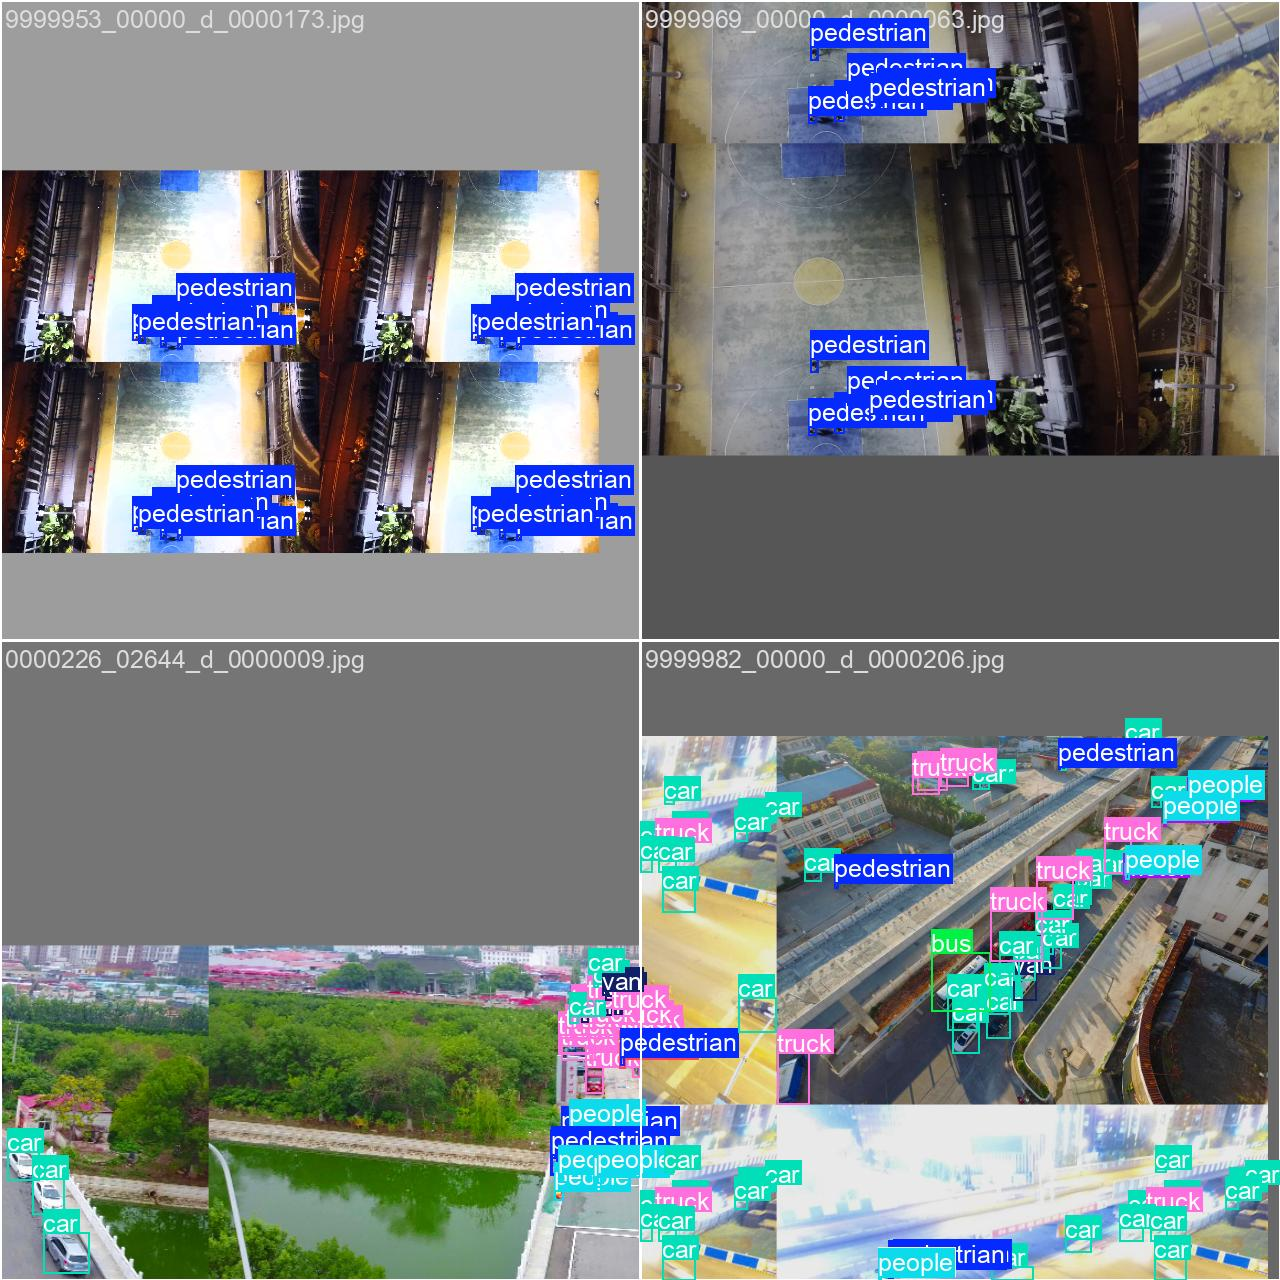

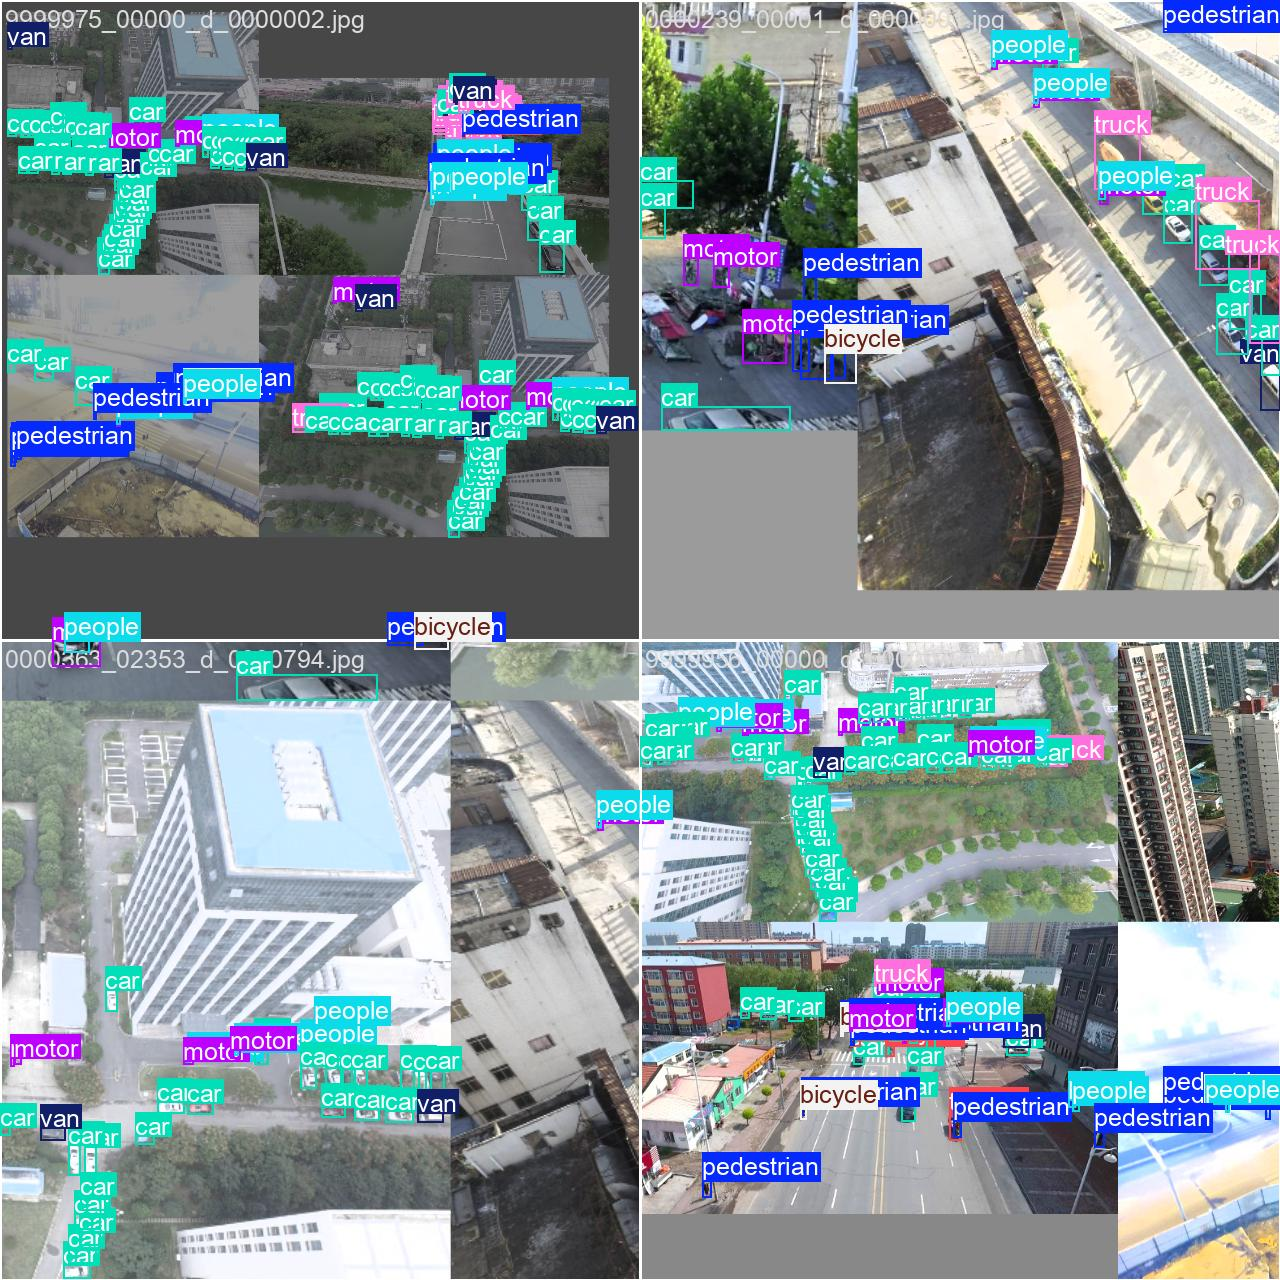

In [8]:
import random

from ultralytics.utils.plotting import plot_images

random.seed(SEED)  # mosaic picks its partner images with `random`
rng = np.random.default_rng(SEED)
for k in range(2):
    idx = rng.choice(len(TRAIN_DS), 4, replace=False)
    batch = TRAIN_DS.collate_fn([TRAIN_DS[int(i)] for i in idx])
    fname = DATA_CHECK_DIR / f"train_batch_preview{k}.jpg"
    plot_images(labels=batch, paths=batch["im_file"], fname=fname, names=data["names"], max_subplots=4, threaded=False)
    display(Image(filename=str(fname), width=900))

### 3d. Class counts and box sizes (`labels.jpg`)

This is the same plot Ultralytics saves at the start of training, drawn here before training begins.
It has four panels:

* **Top left: instances per class.** The imbalance from 3a, as a bar chart.
* **Top right: every box drawn at the centre.** It shows the spread of shapes and sizes at a glance.
* **Bottom left: where box centres fall (x, y).** Healthy is spread across the frame. A tight cluster,
  or a hard edge where there should not be one, points to a coordinate bug.
* **Bottom right: box width vs height (normalised).** For VisDrone, expect most of the mass **packed
  into the bottom-left corner**: boxes a few percent of the image across. That corner is the whole
  reason small-object detection is hard, and the reason input size (Step 6) matters so much.

Plotting labels to /content/drive/MyDrive/jarvis/visdrone_yolov8n/data_checks/labels.jpg... 


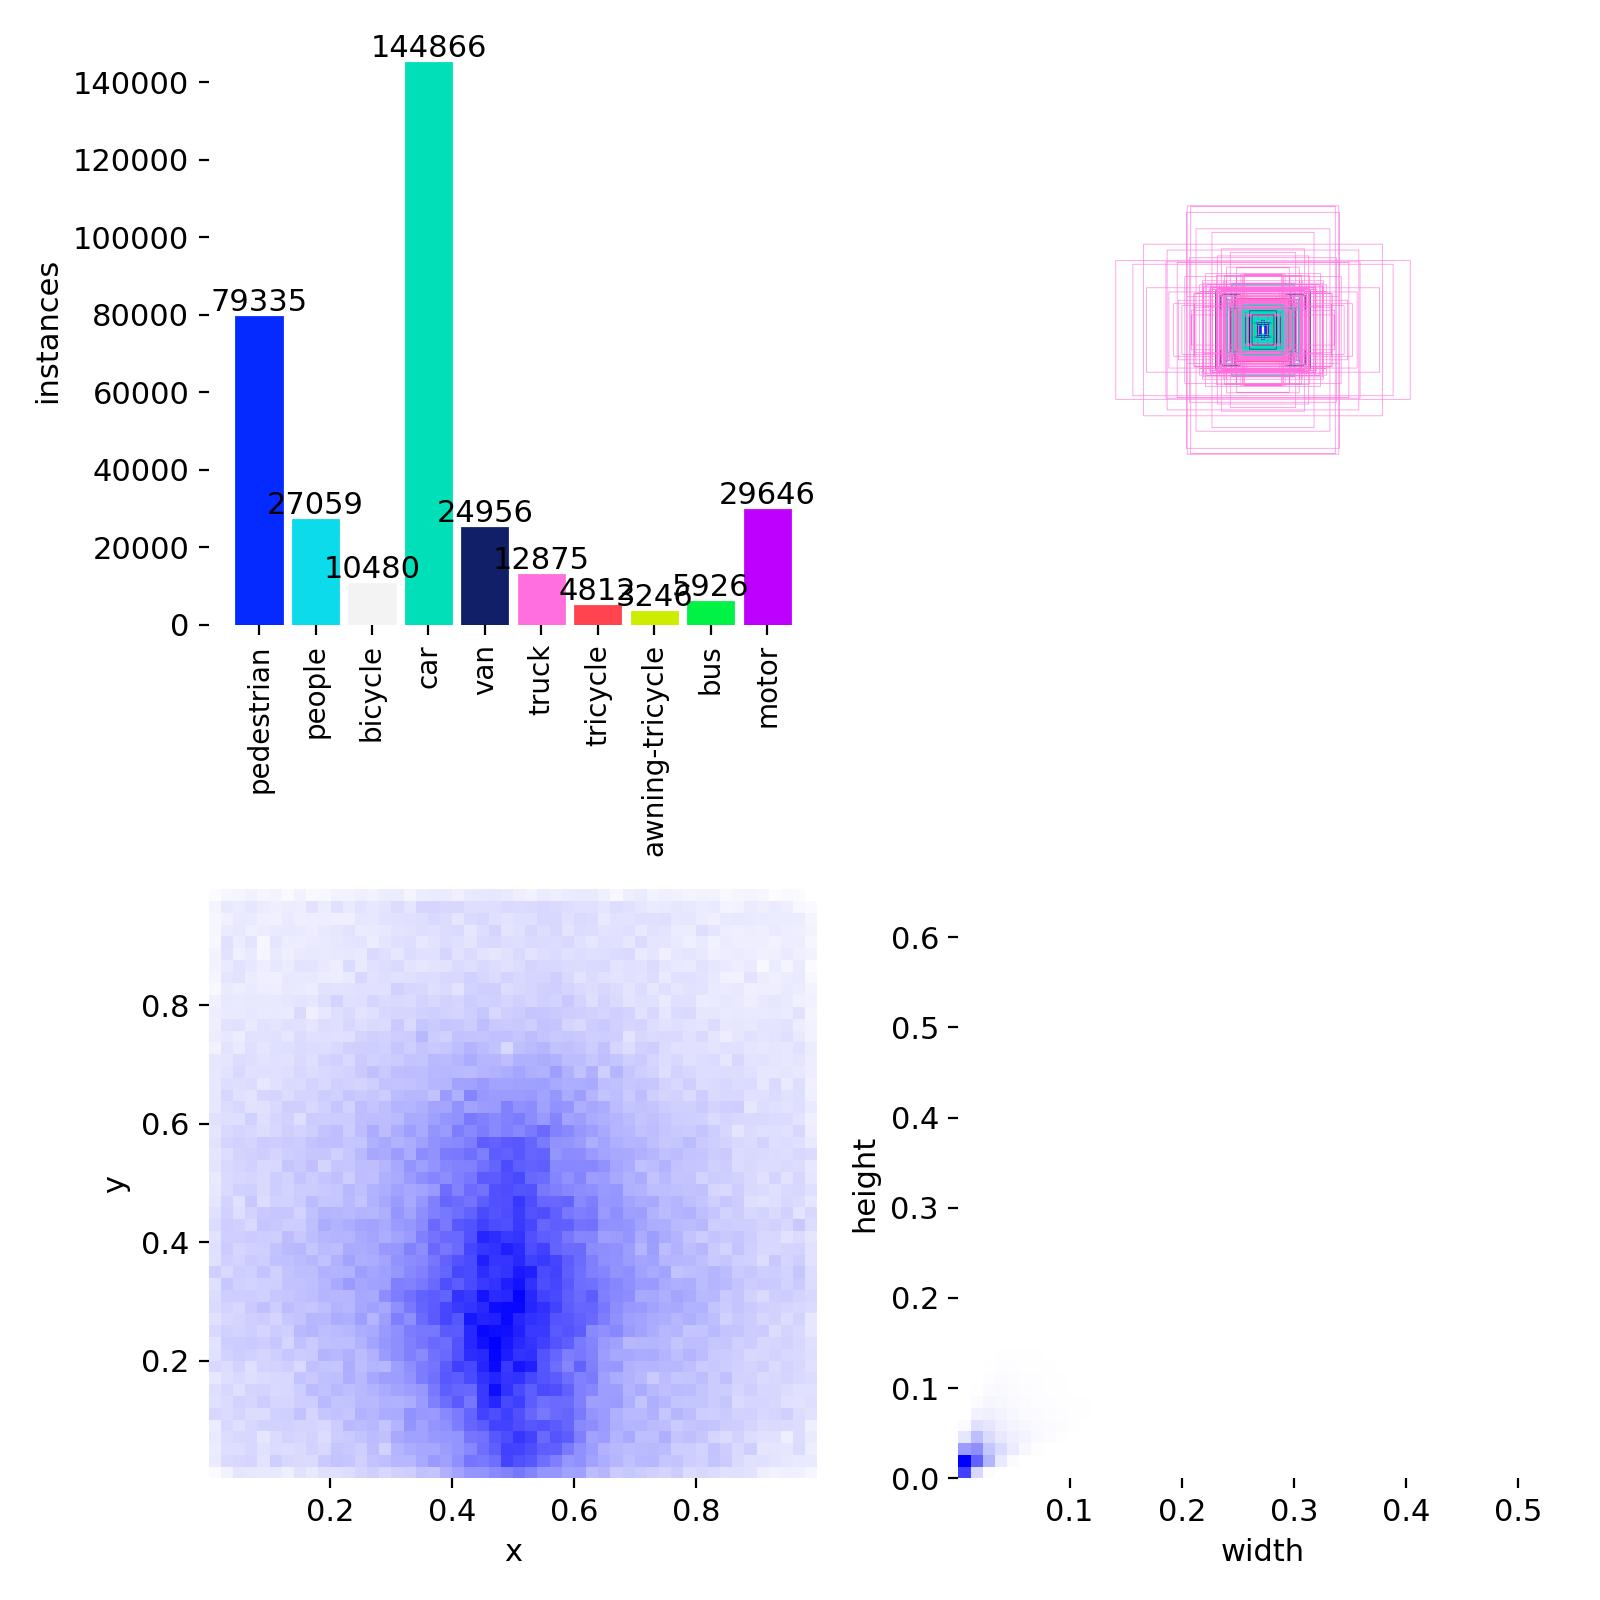

At imgsz=640: median box 11x18 px; 39% of boxes are under 16 px on their long side


In [9]:
from ultralytics.utils.plotting import plot_labels

boxes = np.concatenate([lb["bboxes"] for lb in TRAIN_DS.labels], 0)
plot_labels(boxes, train_cls, names=data["names"], save_dir=DATA_CHECK_DIR)
display(Image(filename=str(DATA_CHECK_DIR / "labels.jpg"), width=700))
w_px, h_px = boxes[:, 2] * IMGSZ, boxes[:, 3] * IMGSZ  # size once the image is resized to IMGSZ
print(f"At imgsz={IMGSZ}: median box {np.median(w_px):.0f}x{np.median(h_px):.0f} px; "
      f"{100 * np.mean(np.maximum(w_px, h_px) < 16):.0f}% of boxes are under 16 px on their long side")

## Step 4 - Sanity check: can the pipeline memorise 10 images? *(optional)*

**What this is.** Before spending hours on 6,471 images, train on **10** of them, and validate on
**the same 10**, for 60 epochs. A working model and pipeline should *memorise* them almost perfectly:
the loss falls steeply and mAP on those images climbs high.

**Why it works as a test.** Memorising 10 images is the easiest task a detector can be given. If it
**cannot** do even that, something is broken at a level no amount of training will fix, for example:
labels that do not line up with the images, a class mapping that is wrong, a learning rate so small
that nothing moves, or a loss that is not connected to the weights. It is much cheaper to find this
out here, in a few minutes, than three hours into the real run.

**What is deliberately switched off, and why:**

* **All augmentation** (mosaic, flips, colour, scale, translate). Augmentation exists to *stop*
  memorisation. Here, memorisation is the goal.
* **Warmup** (`warmup_epochs=0`). Ultralytics warms up for at least 100 *iterations*, which on 10
  images would be most of the test.
* **Gradient accumulation** (`nbs=2`, equal to the batch). By default Ultralytics accumulates
  gradients up to a "nominal batch" of 64 images before each weight update. With a batch of 2 that
  would mean one update every 32 steps, about ten updates in the whole test. Setting `nbs` equal to
  the batch makes every step an update: 5 per epoch, 300 in total.

**Pass criteria (heuristic):**

* **box + cls loss** at the last epoch is **30% or less of the first epoch's**. The DFL loss is left
  out on purpose. It is a cross-entropy against a *spread* target distribution, so even a perfect
  model has a floor above zero, and "near zero" does not apply to it.
* **mAP50 on the 10 memorised images is at least 0.7.** The objects are tiny, so a perfect 1.0 is not
  expected even here, but a working pipeline gets well clear of 0.7.

**If it fails, do not start the full run.** The cell raises an error so that **Run all** stops.
Look at the plots it saves, and at Step 3c, before going further. The thresholds are rules of thumb:
if a result is borderline, look at the curves before concluding anything.

In [10]:
import shutil

SANITY = None
if RUN_SANITY_CHECK:
    SANITY_DIR = Path("/content/sanity")  # throwaway, local disk
    SANITY_EPOCHS, SANITY_N, SANITY_BATCH = 60, 10, 2
    shutil.rmtree(SANITY_DIR, ignore_errors=True)
    (SANITY_DIR / "images" / "train").mkdir(parents=True)
    (SANITY_DIR / "labels" / "train").mkdir(parents=True)

    labelled = [i for i, lb in enumerate(TRAIN_DS.labels) if len(lb["cls"])]
    picks = np.random.default_rng(SEED).choice(labelled, SANITY_N, replace=False)
    for i in picks:
        img = Path(TRAIN_DS.im_files[i])
        shutil.copy2(img, SANITY_DIR / "images" / "train" / img.name)
        shutil.copy2(img2label_paths([str(img)])[0], SANITY_DIR / "labels" / "train" / f"{img.stem}.txt")
    sanity_yaml = SANITY_DIR / "sanity.yaml"
    sanity_yaml.write_text(yaml.safe_dump({"path": str(SANITY_DIR), "train": "images/train",
                                           "val": "images/train",  # same images on purpose
                                           "names": dict(enumerate(VISDRONE_NAMES))}, sort_keys=False))

    YOLO("yolov8n.pt").train(
        data=str(sanity_yaml), epochs=SANITY_EPOCHS, imgsz=IMGSZ, batch=SANITY_BATCH, nbs=SANITY_BATCH,
        seed=SEED, deterministic=True, warmup_epochs=0, device=0, cache="ram",
        mosaic=0.0, close_mosaic=0, mixup=0.0, fliplr=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
        translate=0.0, scale=0.0,
        project="/content/sanity_runs", name="overfit10", exist_ok=True, plots=True, verbose=False,
    )
    sh = pd.read_csv("/content/sanity_runs/overfit10/results.csv")
    sh.columns = sh.columns.str.strip()
    bc = sh["train/box_loss"] + sh["train/cls_loss"]
    SANITY = {
        "images": SANITY_N, "epochs": SANITY_EPOCHS, "batch": SANITY_BATCH,
        "box_cls_loss_first": float(bc.iloc[0]), "box_cls_loss_last": float(bc.iloc[-1]),
        "loss_ratio": float(bc.iloc[-1] / bc.iloc[0]),
        "dfl_loss_first": float(sh["train/dfl_loss"].iloc[0]), "dfl_loss_last": float(sh["train/dfl_loss"].iloc[-1]),
        "map50_final": float(sh["metrics/mAP50(B)"].iloc[-1]),
        "map50_95_final": float(sh["metrics/mAP50-95(B)"].iloc[-1]),
    }
    SANITY["passed"] = SANITY["loss_ratio"] <= 0.30 and SANITY["map50_final"] >= 0.70
    display(Image(filename="/content/sanity_runs/overfit10/results.png", width=1000))
    print(json.dumps({k: round(v, 4) if isinstance(v, float) else v for k, v in SANITY.items()}, indent=2))
    if not SANITY["passed"]:
        raise RuntimeError(
            "SANITY CHECK FAILED - the pipeline could not memorise 10 images "
            f"(box+cls loss ratio {SANITY['loss_ratio']:.2f}, needs <= 0.30; mAP50 {SANITY['map50_final']:.3f}, "
            "needs >= 0.70). Do NOT start the full run: check Step 3c's boxes and the curves above first."
        )
    print("Sanity check PASSED - the pipeline can learn. Proceeding.")
else:
    print("Sanity check skipped (RUN_SANITY_CHECK = False).")

Sanity check skipped (RUN_SANITY_CHECK = False).


## Step 5 - Baseline: the COCO model, before any training

Without a "before" number, the fine-tuned result has nothing to be compared against. The difficulty
is that **the two models do not share a label set.** The COCO model predicts COCO's 80 classes and
knows nothing about VisDrone's 10. Only the classes that *mean the same thing* can be scored.

| VisDrone class | COCO class | Scored in the baseline? |
|---|---|---|
| pedestrian | person | yes - merged into **person** (see below) |
| people | person | yes - merged into **person** |
| bicycle | bicycle | yes |
| car | car | yes |
| truck | truck | yes |
| bus | bus | yes |
| motor | motorcycle | yes |
| **van** | *none* | **no - COCO has no van class** |
| **tricycle** | *none* | **no - COCO has no tricycle class** |
| **awning-tricycle** | *none* | **no - COCO has no awning-tricycle class** |

**These three classes are deliberately left out of the baseline.** They are not scored as zero,
because a zero would read as "the model tried and failed" when in fact it never had those classes to
predict. They only appear in the fine-tuned model's all-10-class numbers in Step 8.

### Why pedestrian and people are merged

VisDrone divides humans **by pose**: `pedestrian` is someone standing or walking, and `people` is
anyone else (sitting, lying, riding a bike). COCO has a single `person` class. If every COCO person
detection were copied into both classes, a correct detection of a seated person would count as a
*false positive* under `pedestrian`. That would penalise the COCO model for a distinction it was never
trained to make. So both are merged into one **person** class, in the ground truth *and* in the
fine-tuned model's predictions when it is scored on this subset. The subset therefore has **6 scored
classes**: person, bicycle, car, truck, bus, motor.

Merging creates one new problem. The fine-tuned model can box the same human as both `pedestrian`
and `people`, and after the merge those are two `person` boxes, one of which would count as a false
positive. So NMS runs again after the remap, with the same IoU threshold of 0.7 as everywhere else.

### Why the unscored classes are treated as "ignore" regions

COCO has no van class, so the COCO model will label a van as `car` or `truck`. The van is not a car in
the ground truth, so each of those boxes would be scored as a *false positive* against the car class.
The baseline would lose points on vans, a class this notebook has just said it will not score.

The fix follows COCO's own convention for regions nobody should be scored on: **a prediction that does
not match any scored box, but overlaps a van, tricycle or awning-tricycle box, is ignored.** It counts
as neither a hit nor a miss. The **same rule applies to both models.** To show how much the rule
changes the outcome, the numbers without it are also reported.

### How AP is computed (the evaluator used on the subset)

* **IoU** (intersection over union) measures how much a predicted box overlaps a ground-truth box, from
  0 (no overlap) to 1 (identical).
* For each class and each IoU threshold, predictions are taken **in order of confidence**. Each one
  claims the unclaimed ground-truth box it overlaps most, if that overlap is at or above the
  threshold. A prediction that claims a box is a true positive; one that finds nothing is a false
  positive.
* Moving down that ordered list traces out a **precision-recall curve**. **AP** is the area under it,
  using COCO's 101-point interpolation.
* **mAP50** is AP at IoU 0.5, averaged over classes: it asks whether the box is roughly in the right
  place. **mAP50-95** averages AP over IoU 0.50, 0.55, ..., 0.95: it also rewards boxes that fit
  *tightly*, which is much harder when an object is 12 pixels wide.

This evaluator is a small reimplementation, so Step 8 **checks it against Ultralytics' own `val()`**
on all 10 classes. If the two agree there, its subset numbers can be trusted.

The baseline is scored on **both** val and test-dev. The COCO model never saw either split, but
the fine-tuned model's headline number is on test-dev, so the like-for-like comparison has to be
on test-dev as well.

In [11]:
import torchvision

IOU_THRESHOLDS = np.linspace(0.5, 0.95, 10)

# ---- The mapped subset -----------------------------------------------------------------
SUBSET_NAMES = ["person", "bicycle", "car", "truck", "bus", "motor"]
COCO_TO_SUBSET = {0: 0, 1: 1, 2: 2, 7: 3, 5: 4, 3: 5}  # person, bicycle, car, truck, bus, motorcycle
VISDRONE_TO_SUBSET = {0: 0, 1: 0, 2: 1, 3: 2, 5: 3, 8: 4, 9: 5}  # pedestrian+people -> person
VISDRONE_UNSCORED = {4: "van", 6: "tricycle", 7: "awning-tricycle"}  # no COCO equivalent -> ignore regions
IDENTITY_10 = {i: i for i in range(len(VISDRONE_NAMES))}


def predict_all(weights, image_paths, classes=None):
    # Run a model over every image; keep raw boxes in the model's OWN class ids.
    model = YOLO(weights)
    out = {}
    list_file = Path("/content/predict_list.txt")
    list_file.write_text("\n".join(str(p) for p in image_paths))
    for r in model.predict(source=str(list_file), stream=True, imgsz=IMGSZ, conf=CONF, iou=NMS_IOU,
                           max_det=MAX_DET, classes=classes, device=0, batch=16, verbose=False):
        b = r.boxes
        out[Path(r.path).stem] = {"xyxy": b.xyxy.cpu().numpy(), "conf": b.conf.cpu().numpy(),
                                  "cls": b.cls.cpu().numpy().astype(int), "shape": r.orig_shape}
    return out


def to_eval_space(preds, class_map):
    # Relabel predictions into evaluation class ids, drop unmapped ones, and re-run NMS so that
    # two source classes merged into one (pedestrian + people -> person) can't double-count.
    out = {}
    for stem, p in preds.items():
        new_cls = np.array([class_map.get(int(c), -1) for c in p["cls"]], dtype=int)
        keep = new_cls >= 0
        xyxy, conf, cls = p["xyxy"][keep], p["conf"][keep], new_cls[keep]
        if len(xyxy):
            idx = torchvision.ops.batched_nms(torch.from_numpy(xyxy).float(), torch.from_numpy(conf).float(),
                                              torch.from_numpy(cls), NMS_IOU).numpy()[:MAX_DET]
            xyxy, conf, cls = xyxy[idx], conf[idx], cls[idx]
        out[stem] = {"xyxy": xyxy, "conf": conf, "cls": cls, "shape": p["shape"]}
    return out


def xywhn_to_xyxy(xywhn, h, w):
    xc, yc, bw, bh = xywhn[:, 0] * w, xywhn[:, 1] * h, xywhn[:, 2] * w, xywhn[:, 3] * h
    return np.stack([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2], axis=1)


def box_iou(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    tl = np.maximum(a[:, None, :2], b[None, :, :2])
    br = np.minimum(a[:, None, 2:], b[None, :, 2:])
    inter = np.clip(br - tl, 0, None).prod(2)
    area_a = (a[:, 2:] - a[:, :2]).prod(1)
    area_b = (b[:, 2:] - b[:, :2]).prod(1)
    return inter / (area_a[:, None] + area_b[None, :] - inter + 1e-9)


def match(pred_boxes, gt_boxes, ignore_boxes):
    # Greedy COCO matching for ONE image and ONE class. pred_boxes must be sorted by confidence (desc).
    # Returns tp[P, T] and ignored[P, T] booleans, one column per IoU threshold.
    P, T = len(pred_boxes), len(IOU_THRESHOLDS)
    tp, ignored = np.zeros((P, T), bool), np.zeros((P, T), bool)
    if P == 0:
        return tp, ignored
    iou = box_iou(pred_boxes, gt_boxes)
    ign_iou = box_iou(pred_boxes, ignore_boxes).max(1) if len(ignore_boxes) else np.zeros(P)
    for t, thr in enumerate(IOU_THRESHOLDS):
        taken = np.zeros(len(gt_boxes), bool)
        for i in range(P):
            if len(gt_boxes):
                cand = np.where(~taken & (iou[i] >= thr), iou[i], -1.0)
                j = int(cand.argmax())
                if cand[j] >= thr:
                    tp[i, t], taken[j] = True, True
                    continue
            if ign_iou[i] >= thr:
                ignored[i, t] = True  # sits on an unscored object: neither hit nor miss
    return tp, ignored


def average_precision(conf, tp, n_gt):
    # COCO 101-point interpolated AP for one class at one IoU threshold.
    if n_gt == 0:
        return float("nan")
    order = np.argsort(-conf, kind="stable")
    tp = tp[order]
    ctp, cfp = np.cumsum(tp), np.cumsum(~tp)
    recall = ctp / n_gt
    precision = ctp / np.maximum(ctp + cfp, 1e-9)
    precision = np.maximum.accumulate(precision[::-1])[::-1]  # envelope: best precision at >= this recall
    idx = np.searchsorted(recall, np.linspace(0, 1, 101), side="left")
    return float(np.mean([precision[i] if i < len(precision) else 0.0 for i in idx]))


def evaluate(preds, gts, gt_map, ignore_gt_classes, class_names):
    # preds are already in eval space (see to_eval_space). Returns ap[C, T] and n_gt[C].
    C, T = len(class_names), len(IOU_THRESHOLDS)
    acc = {c: {"conf": [], "tp": [], "ign": []} for c in range(C)}
    n_gt = np.zeros(C, int)
    ignore_ids = list(ignore_gt_classes)
    for stem, g in gts.items():
        p = preds[stem]
        h, w = p["shape"]
        g_xyxy = xywhn_to_xyxy(g["xywhn"], h, w)
        g_cls = np.array([gt_map.get(int(c), -1) for c in g["cls"]], dtype=int)
        ign_boxes = g_xyxy[np.isin(g["cls"], ignore_ids)]
        for c in range(C):
            gb = g_xyxy[g_cls == c]
            n_gt[c] += len(gb)
            m = p["cls"] == c
            order = np.argsort(-p["conf"][m], kind="stable")
            tp, ign = match(p["xyxy"][m][order], gb, ign_boxes)
            acc[c]["conf"].append(p["conf"][m][order])
            acc[c]["tp"].append(tp)
            acc[c]["ign"].append(ign)
    ap = np.full((C, T), np.nan)
    for c in range(C):
        conf = np.concatenate(acc[c]["conf"])
        tp = np.concatenate(acc[c]["tp"]).reshape(-1, T)
        ign = np.concatenate(acc[c]["ign"]).reshape(-1, T)
        for t in range(T):
            keep = ~ign[:, t]
            ap[c, t] = average_precision(conf[keep], tp[keep, t], n_gt[c])
    return ap, n_gt


def summarize(ap, n_gt, class_names):
    return {
        "map50": float(np.nanmean(ap[:, 0])),
        "map50_95": float(np.nanmean(ap.mean(1))),
        "per_class": [{"class": n, "gt_instances": int(k), "ap50": float(ap[i, 0]), "ap50_95": float(ap[i].mean())}
                      for i, (n, k) in enumerate(zip(class_names, n_gt))],
    }


def subset_scores(preds_in_subset_space, gts):
    # Mapped-subset scores with the ignore rule (headline) and without it (sensitivity).
    with_ignore = summarize(*evaluate(preds_in_subset_space, gts, VISDRONE_TO_SUBSET, VISDRONE_UNSCORED,
                                      SUBSET_NAMES), SUBSET_NAMES)
    no_ignore = summarize(*evaluate(preds_in_subset_space, gts, VISDRONE_TO_SUBSET, (), SUBSET_NAMES), SUBSET_NAMES)
    return with_ignore, {k: no_ignore[k] for k in ("map50", "map50_95")}

### Run the baseline

`classes=[...]` makes the COCO model return **only** the six mapped COCO classes. Without it, boxes
for classes that are about to be discarded (traffic lights, boats and so on) would use up part of the
300-box `max_det` budget in crowded images, and the baseline would lose real detections for no reason.

In [12]:
import torch
print("GPU in use before baseline:", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")
imgs0 = next(iter(SPLITS.values()))[0]
print("IMGSZ:", IMGSZ)
print("images container:", type(imgs0), "| count:", len(imgs0))
print("first item:", type(imgs0[0]), getattr(imgs0[0], "shape", imgs0[0]))

GPU in use before baseline: 0.0 GB
IMGSZ: 640
images container: <class 'list'> | count: 548
first item: <class 'str'> /content/datasets/VisDrone/images/val/0000001_02999_d_0000005.jpg


In [13]:
BASELINE_SUBSET, BASELINE_SUBSET_NO_IGNORE = {}, {}
for split, (images, gts, _) in SPLITS.items():
    raw = predict_all("yolov8n.pt", images, classes=sorted(COCO_TO_SUBSET))
    BASELINE_SUBSET[split], BASELINE_SUBSET_NO_IGNORE[split] = subset_scores(to_eval_space(raw, COCO_TO_SUBSET), gts)
    print(f"Baseline (COCO yolov8n), {split:8s} mapped subset: mAP50 {BASELINE_SUBSET[split]['map50']:.4f} | "
          f"mAP50-95 {BASELINE_SUBSET[split]['map50_95']:.4f}   (no ignore rule: mAP50 "
          f"{BASELINE_SUBSET_NO_IGNORE[split]['map50']:.4f})")
print("Not scored (no COCO equivalent):", ", ".join(VISDRONE_UNSCORED.values()))
pd.DataFrame(BASELINE_SUBSET["test-dev"]["per_class"]).round(4)

Baseline (COCO yolov8n), val      mapped subset: mAP50 0.1302 | mAP50-95 0.0739   (no ignore rule: mAP50 0.1210)
Baseline (COCO yolov8n), test-dev mapped subset: mAP50 0.0592 | mAP50-95 0.0317   (no ignore rule: mAP50 0.0553)
Not scored (no COCO equivalent): van, tricycle, awning-tricycle


,class,gt_instances,ap50,ap50_95
0,person,27382,0.0788,0.0345
1,bicycle,1302,0.0014,0.0004
2,car,28074,0.1980,0.1083
3,truck,2659,0.0490,0.0287
4,bus,2940,0.0185,0.0142
5,motor,5845,0.0096,0.0042


Expect these numbers to be **low**. That is the point of measuring them. A COCO person is usually
photographed from the side and fills a good part of the frame. A VisDrone pedestrian is seen from
above, from tens of metres up, and is often only 10-20 pixels tall. The object is the same but it
looks nothing alike, and that gap is what fine-tuning has to close.

## Step 6 - Train

**Fine-tuning** means training does not start from random weights. It starts from `yolov8n.pt`,
which already knows edges, textures and shapes from COCO, and continues on VisDrone. Ultralytics
notices that the dataset has 10 classes rather than 80 and **re-initialises only the class-prediction
layers** of the detection head. The log line `Transferred X/Y items from pretrained weights` shows
this: nearly everything is carried over, and the few layers that are not are the ones sized for 80
classes.

Settings, and why each one:

* **`epochs=50`**: one epoch is one full pass over the 6,471 training images.
* **`seed=42`, `deterministic=True`**: fixes the random choices (data shuffling, augmentation) so a
  rerun follows the same path. *Caveat:* some GPU kernels are not bit-exact even with this setting,
  and a different GPU model will diverge slightly. The results are reproducible to within a small
  amount of noise, not to every digit.
* **`batch=16`**: fixed. AutoBatch (`-1`) chooses a batch size from the GPU's memory, so a T4 and an
  L4 would train different experiments.
* **`patience=EPOCHS`**: turns early stopping off in effect, so the run is exactly 50 epochs. The
  record then says what happened rather than "up to 50".
* **`close_mosaic=10`**: mosaic augmentation is switched off for the last 10 epochs (Step 7 explains
  what that does to the curves).

### Why imgsz stays at 640

> **Larger input sizes help small objects, and VisDrone is mostly small objects**, so training at 960
> or 1280 would very likely score noticeably higher. But the input size is also **what the detector
> costs to run**: compute grows roughly with the square of the side, so 1280 is about 4x the work of
> 640, and fps falls to match. 640 is the input size of the speed target that the next step
> benchmarks, and a model trained at 640 is the one that will actually run at that speed. Training
> larger and then running at 640 does not solve this: the model learns object sizes at the scale it
> was trained on. If small-object accuracy turns out to be the limit, make it its own experiment,
> with its fps measured next to its mAP.

### Resuming

Every epoch, Ultralytics writes `weights/last.pt` (the model plus the optimizer state, the
learning-rate schedule position and the epoch number) to the run directory on Drive. The cell below
checks that file:

* **no `last.pt`**: start fresh from `yolov8n.pt`;
* **`last.pt` part-way through**: `resume=True` continues from the next epoch with the original
  arguments, which are read back out of the checkpoint;
* **finished**: skip. When Ultralytics completes the final epoch it strips the checkpoint and marks
  it `epoch = -1`, and that marker is how this cell knows. Calling `resume=True` on a finished run
  raises an error, which is why the cell checks first.

On a T4, expect this to take roughly a few hours. Colab sessions can end before that, and that is
what the resume path is for.

In [14]:
RUN_DIR = RUNS_DIR / RUN_NAME
LAST_PT = RUN_DIR / "weights" / "last.pt"
BEST_PT = RUN_DIR / "weights" / "best.pt"


def training_state():
    if not LAST_PT.exists():
        return "fresh", 0
    ckpt = torch.load(LAST_PT, map_location="cpu", weights_only=False)
    epoch = ckpt.get("epoch", -1)  # 0-based index of the last COMPLETED epoch; -1 once finalised
    if epoch == -1 or epoch + 1 >= EPOCHS:
        return "finished", EPOCHS
    return "resume", epoch + 1


state, done = training_state()
print(f"Run: {RUN_DIR}\nState: {state} ({done}/{EPOCHS} epochs complete)")

if state == "fresh":
    YOLO("yolov8n.pt").train(
        data=str(DATA_YAML), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH,
        seed=SEED, deterministic=True, patience=EPOCHS, close_mosaic=CLOSE_MOSAIC,
        project=str(RUNS_DIR), name=RUN_NAME, exist_ok=True, device=0, plots=True,
    )
elif state == "resume":
    YOLO(str(LAST_PT)).train(resume=True)
else:
    print(f"Training already finished - skipping. Delete {RUN_DIR} to retrain from scratch.")

assert BEST_PT.exists(), f"No best.pt at {BEST_PT} - training did not complete."

Run: /content/drive/MyDrive/jarvis/visdrone_yolov8n/runs/yolov8n_visdrone_640_e50_s42
State: finished (50/50 epochs complete)
Training already finished - skipping. Delete /content/drive/MyDrive/jarvis/visdrone_yolov8n/runs/yolov8n_visdrone_640_e50_s42 to retrain from scratch.


## Step 7 - Training diagnostics

The curves below come from `results.csv`, the per-epoch log Ultralytics writes to Drive. Every plot
has a dashed line where **mosaic switches off** (`close_mosaic`). Here is what to expect there, so it
is not mistaken for a problem.

> **The close_mosaic bump.** For the last 10 epochs the model trains on plain, un-tiled images, which
> look like the images it will actually be run on. The switch changes what the model sees overnight,
> so the **training losses step** (usually *down*: plain images are easier than mosaics) and **val
> mAP often jumps up** a little. A kink right at the dashed line is expected and healthy. A kink
> anywhere else, especially an upward spike in loss, is not.

### 7a. The overview (`results.png`)

Ultralytics' own summary shows every tracked series in one grid, with training losses on the top
row and validation losses and metrics on the bottom. The plots after it break the important ones
out one at a time, so they are easier to read.

Epochs completed: 50 | mosaic off from epoch 41


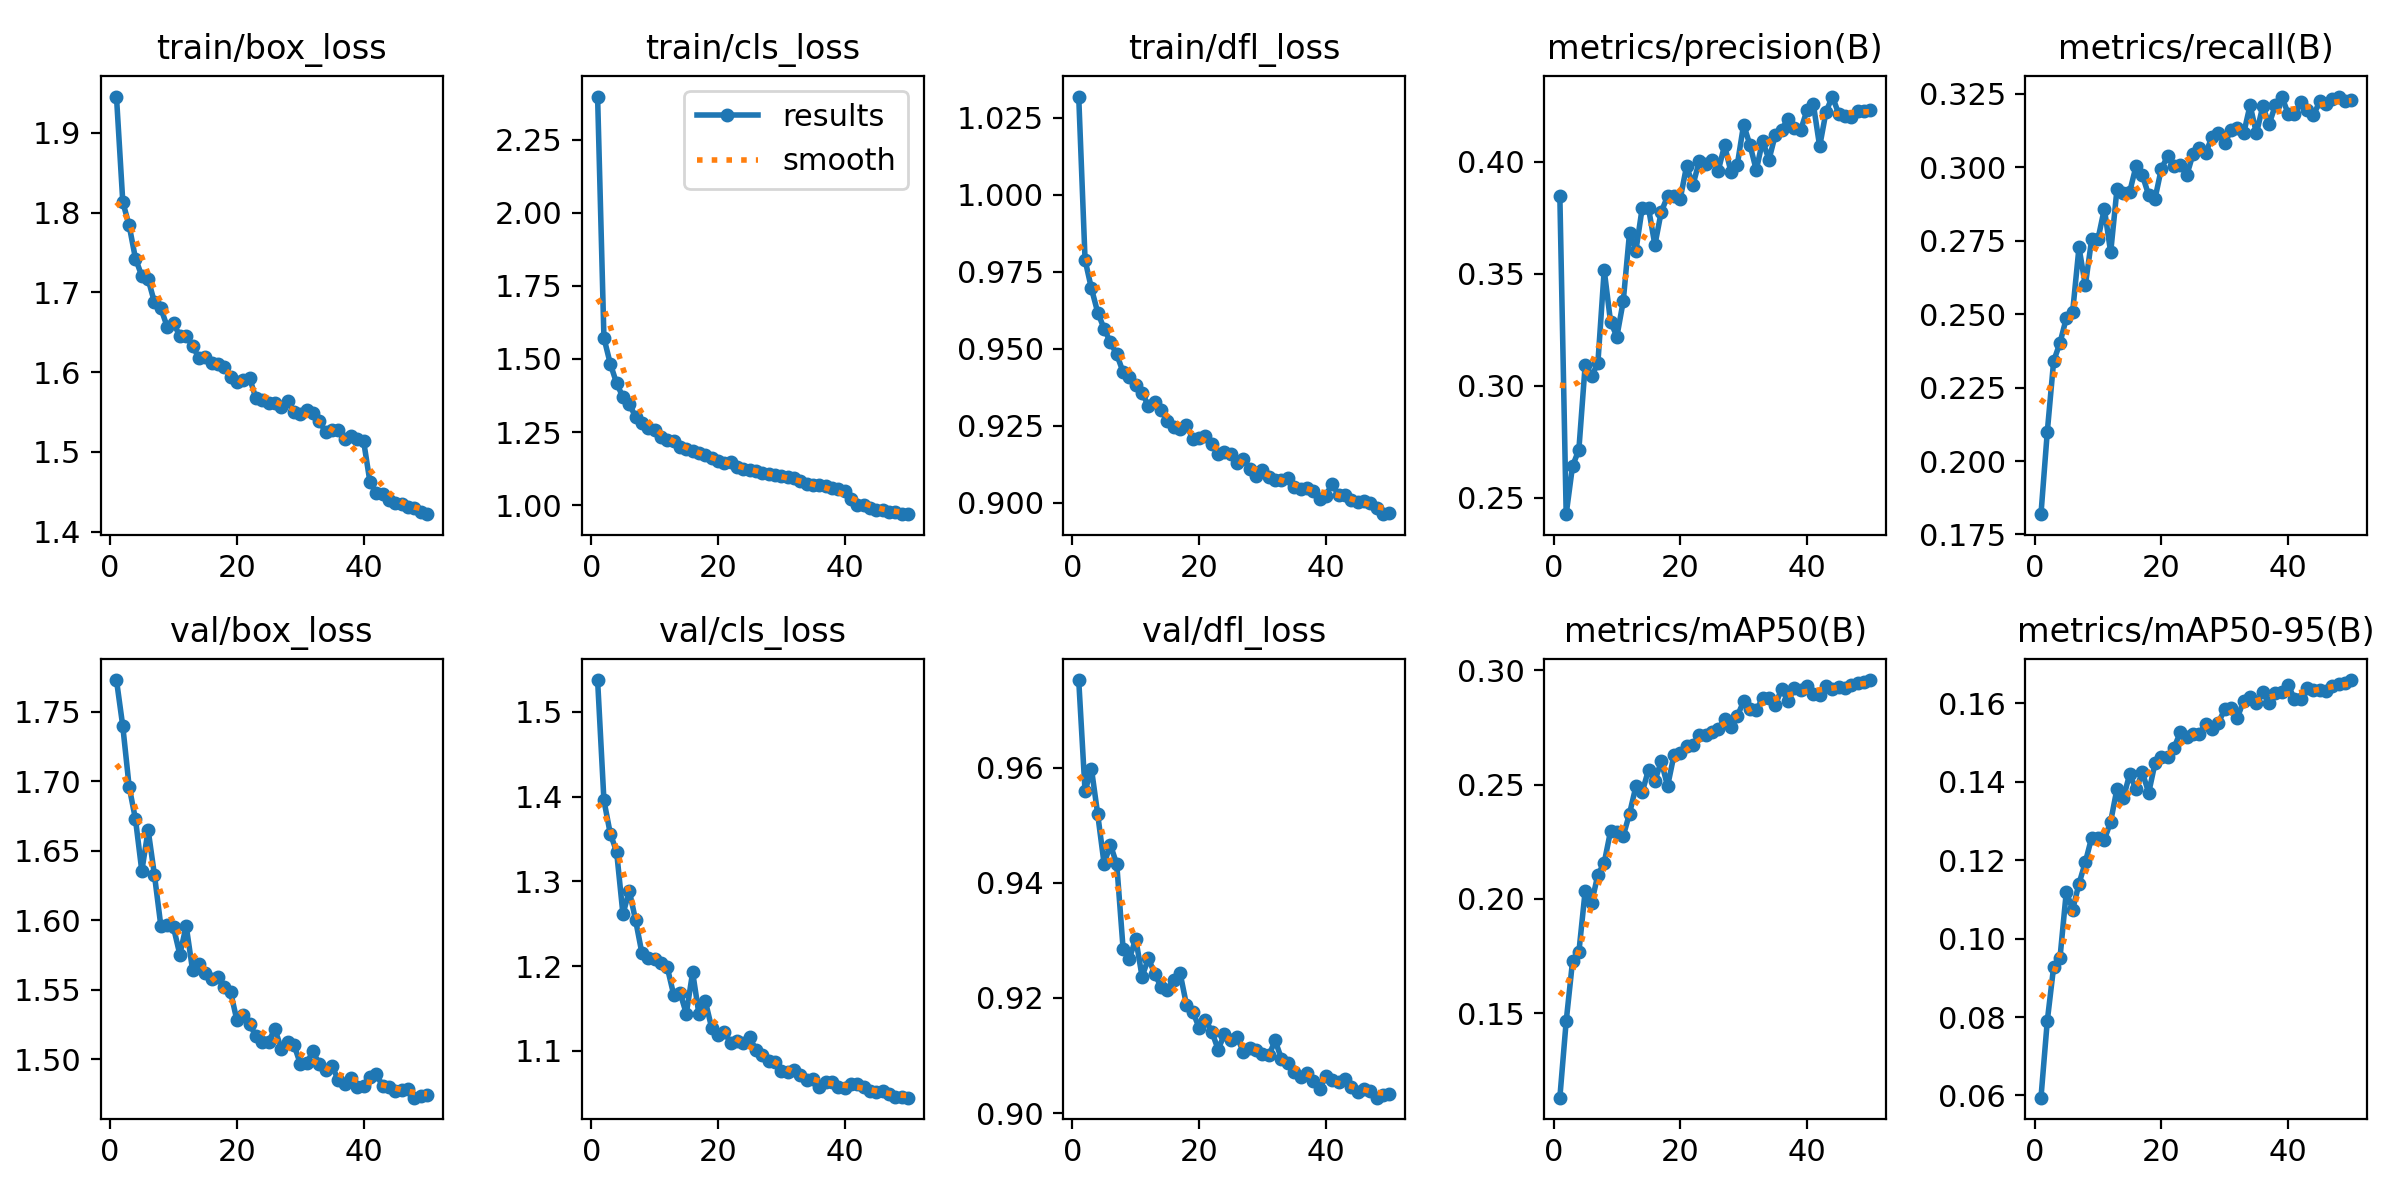

In [15]:
import matplotlib.pyplot as plt

H = pd.read_csv(RUN_DIR / "results.csv")
H.columns = H.columns.str.strip()
EPOCHS_COMPLETED = len(H)
MOSAIC_OFF_EPOCH = EPOCHS - CLOSE_MOSAIC + 1  # first (1-based) epoch trained without mosaic
print(f"Epochs completed: {EPOCHS_COMPLETED} | mosaic off from epoch {MOSAIC_OFF_EPOCH}")


def mark_close_mosaic(ax):
    ax.axvline(MOSAIC_OFF_EPOCH - 0.5, ls="--", c="grey", lw=1)
    ax.text(MOSAIC_OFF_EPOCH - 0.5, ax.get_ylim()[1], " mosaic off", va="top", ha="left", fontsize=8, c="grey")


display(Image(filename=str(RUN_DIR / "results.png"), width=1000))

### 7b. Training vs validation loss (box, cls, dfl)

There are three losses, and each one measures a different job:

* **box**: how well the predicted boxes overlap the true ones (CIoU).
* **cls**: whether the class of each box is right (binary cross-entropy).
* **dfl**: distribution focal loss, which sharpens box *edges*. It has a floor above zero, so do not
  expect it to reach zero.

**Healthy:** both curves fall and then flatten, with **val a little above train and the gap staying
roughly constant**.

**Overfitting:** training loss keeps falling while **val loss turns and climbs**, and the gap widens.
The model is memorising the training images instead of learning to generalise. `best.pt` protects
against this, because it keeps the best val epoch rather than the last one. It is still a sign that
more epochs would not help, and more data or augmentation would.

**Underfitting:** **both** curves are still clearly falling at the last epoch. The model has not
finished learning, and more epochs (or a bigger model) would help.

**Broken:** val loss far above train from the very first epoch, or losses that jump around or go to
NaN. That points to a data mismatch or a learning rate that is too high.

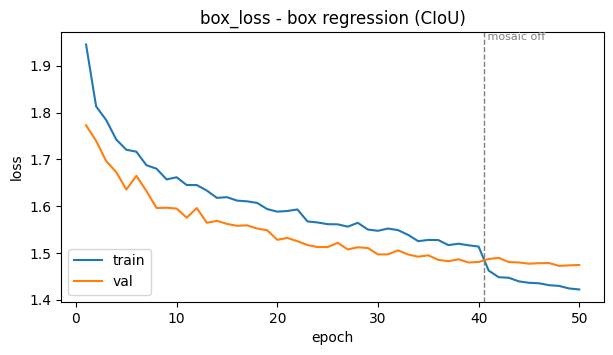

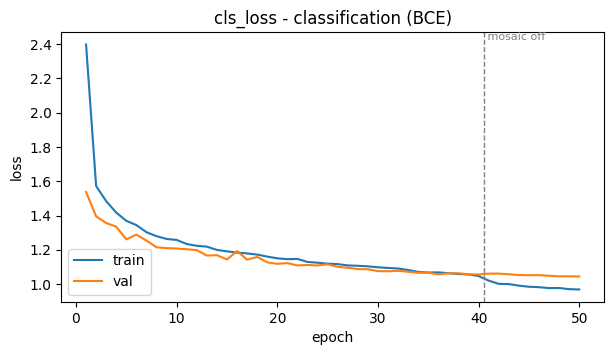

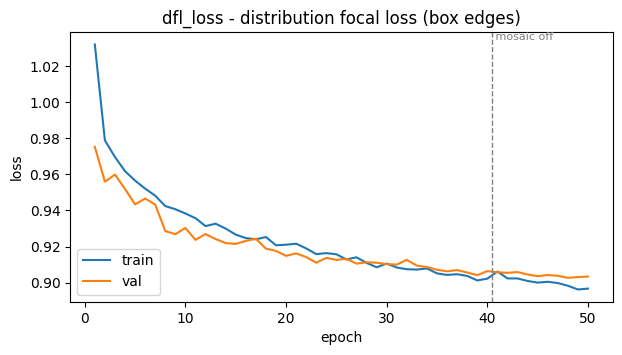

In [16]:
for comp, what in [("box", "box regression (CIoU)"), ("cls", "classification (BCE)"),
                   ("dfl", "distribution focal loss (box edges)")]:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(H["epoch"], H[f"train/{comp}_loss"], label="train")
    ax.plot(H["epoch"], H[f"val/{comp}_loss"], label="val")
    ax.set(title=f"{comp}_loss - {what}", xlabel="epoch", ylabel="loss")
    ax.legend()
    mark_close_mosaic(ax)
    plt.show()

### 7c. Learning rate per epoch

The **learning rate** is the step size of each weight update. Ultralytics' schedule has two phases:

1. **Warmup** (the first 3 epochs): the rate ramps *up* from near zero, so the large gradients in
   the first steps cannot wreck the pretrained weights. The **bias** group (`pg2`) instead starts
   *high* and ramps *down*, which is why one line comes in from above.
2. **Linear decay** to 1% of the starting rate by the final epoch. Smaller steps at the end let the
   weights settle.

The three lines are the optimizer's parameter groups: `pg0` holds the weights with weight decay,
`pg1` the batch-norm weights (no decay), and `pg2` the biases.

**Healthy:** a smooth ramp and then a straight descent. The rate is *not* changed at the mosaic line.
That line is here because it marks where the regime changes, and it helps to see it against the
schedule. **Unhealthy:** a flat line (the schedule is not being applied) or a jump part-way through
(usually a resume that restarted the schedule, which would show in the loss curves too).

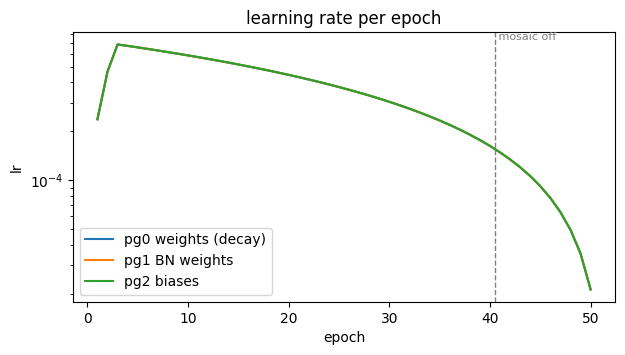

In [17]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for col, label in [("lr/pg0", "pg0 weights (decay)"), ("lr/pg1", "pg1 BN weights"), ("lr/pg2", "pg2 biases")]:
    ax.plot(H["epoch"], H[col], label=label)
ax.set(title="learning rate per epoch", xlabel="epoch", ylabel="lr", yscale="log")
ax.legend()
mark_close_mosaic(ax)
plt.show()

### 7d. mAP50 and mAP50-95 per epoch (on val)

**Healthy:** a fast rise in the first few epochs, a slower climb, then a plateau, often with a small
extra lift after the mosaic line. mAP50-95 always sits well below mAP50, because tight boxes are
harder than roughly right ones.

**Overfitting:** mAP peaks and then **declines**. **Underfitting:** mAP is **still rising steeply**
at the last epoch. **Worth a look:** a mAP that is flat from epoch 1, which suggests the model is not
learning the new classes at all (check the sanity step and the labels).

The dot marks the epoch Ultralytics saved as `best.pt`. It picks the epoch with the best *fitness*,
which in Ultralytics 8.4.60 is mAP50-95 alone, so the dot can sit a little off the mAP50 peak.

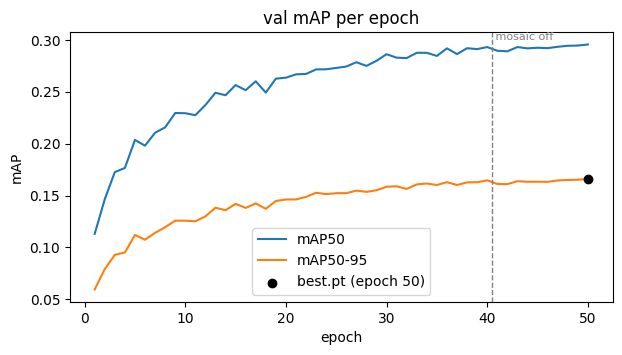

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(H["epoch"], H["metrics/mAP50(B)"], label="mAP50")
ax.plot(H["epoch"], H["metrics/mAP50-95(B)"], label="mAP50-95")
best_row = H.loc[H["metrics/mAP50-95(B)"].idxmax()]  # Ultralytics 8.4.60 fitness = mAP50-95
ax.scatter([best_row["epoch"]], [best_row["metrics/mAP50-95(B)"]], c="k", zorder=3,
           label=f"best.pt (epoch {int(best_row['epoch'])})")
ax.set(title="val mAP per epoch", xlabel="epoch", ylabel="mAP")
ax.legend()
mark_close_mosaic(ax)
plt.show()

## Step 8 - Evaluate

`best.pt` is scored on both splits with Ultralytics' own `val()`, over all 10 classes:

* **test-dev = the headline.** Nothing was chosen on it.
* **val = alongside.** It was used to pick `best.pt`, so expect it to be the same or slightly higher.
  A test-dev score far *below* val would mean the choices made on val do not carry over to new
  images.

The diagnostic plots that follow (confusion matrix, PR curve, F1 curve, sample predictions) are the
**val** ones. That keeps a clean discipline: tuning decisions, like the deployment threshold, are
made on val, and test-dev is only ever *scored*, never looked at for choices. Ultralytics saves the
same plots for test-dev under `eval/finetuned_test-dev/` if you want to compare them afterwards.

In [19]:
FT_ALL10, VAL_METRICS = {}, {}
for split, ul_split in [("val", "val"), ("test-dev", "test")]:
    m = YOLO(str(BEST_PT)).val(
        data=str(DATA_YAML), split=ul_split, imgsz=IMGSZ, batch=BATCH, conf=CONF, iou=NMS_IOU, max_det=MAX_DET,
        device=0, project=str(EVAL_DIR), name=f"finetuned_{split}", exist_ok=True, plots=True, verbose=False,
    )
    VAL_METRICS[split] = m
    box = m.box
    FT_ALL10[split] = {
        "evaluator": "ultralytics val()",
        "map50": float(box.map50), "map50_95": float(box.map),
        "precision": float(box.mp), "recall": float(box.mr),
        "per_class": [
            {"class": VISDRONE_NAMES[int(c)], "gt_instances": int(COUNTS[split][int(c)]),
             "precision": float(box.p[k]), "recall": float(box.r[k]),
             "ap50": float(box.ap50[k]), "ap50_95": float(box.ap[k])}
            for k, c in enumerate(box.ap_class_index)
        ],
    }

print("Fine-tuned YOLOv8n, all 10 classes")
for split in ("test-dev", "val"):
    tag = "HEADLINE" if split == "test-dev" else "val (used to pick best.pt)"
    print(f"  {split:8s} mAP50 {FT_ALL10[split]['map50']:.4f} | mAP50-95 {FT_ALL10[split]['map50_95']:.4f}   <- {tag}")
VAL_PLOTS = Path(VAL_METRICS["val"].save_dir)

Ultralytics 8.4.60 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2907.8±1104.1 MB/s, size: 134.4 KB)
val: Scanning /content/datasets/VisDrone/labels/val... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 1.4Kit/s 0.4s
val: New cache created: /content/datasets/VisDrone/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.3it/s 15.2s
                   all        548      38759      0.425      0.324      0.297      0.166
Speed: 1.4ms preprocess, 3.0ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /content/drive/MyDrive/jarvis/visdrone_yolov8n/eval/finetuned_val
Ultralytics 8.4.60 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: 

### 8a. Per-class AP, test-dev vs val

**Healthy:** the common classes (car, pedestrian) score highest, and test-dev sits close to val in
every row.

**Class imbalance shows up here.** Compare this table with the instance counts from Step 3a. The
rare classes (awning-tricycle, tricycle, bicycle, bus) usually score lowest. The model has seen far
fewer of them, and several of them look like one another from above. **A row where test-dev is far
below val** is worth a note: with few instances, a class's AP is noisy, and it can also mean the
model latched onto something that only holds in val.

In [20]:
t = pd.DataFrame(FT_ALL10["test-dev"]["per_class"]).set_index("class")
v = pd.DataFrame(FT_ALL10["val"]["per_class"]).set_index("class")
per_class = pd.DataFrame({
    "train instances": pd.Series(COUNTS["train"], index=VISDRONE_NAMES),
    "test-dev instances": t["gt_instances"],
    "test-dev AP50": t["ap50"], "test-dev AP50-95": t["ap50_95"],
    "val AP50": v["ap50"], "val AP50-95": v["ap50_95"],
})
per_class["AP50 gap (val - test)"] = per_class["val AP50"] - per_class["test-dev AP50"]
per_class.sort_values("train instances", ascending=False).round(4)

,train instances,test-dev instances,test-dev AP50,test-dev AP50-95,val AP50,val AP50-95,AP50 gap (val - test)
car,144866,28074,0.6450,0.3835,0.7232,0.4739,0.0782
pedestrian,79335,21006,0.1962,0.0726,0.3049,0.1210,0.1088
motor,29646,5845,0.1914,0.0692,0.3190,0.1223,0.1275
people,27059,6376,0.1012,0.0312,0.2347,0.0771,0.1335
van,24956,5771,0.2731,0.1699,0.3335,0.2246,0.0604
truck,12875,2659,0.3185,0.1943,0.2818,0.1768,-0.0366
bicycle,10480,1302,0.0512,0.0188,0.0643,0.0236,0.0130
bus,5926,2940,0.4876,0.3233,0.4089,0.2788,-0.0787
tricycle,4812,530,0.1147,0.0581,0.1948,0.1013,0.0802
awning-tricycle,3246,599,0.1220,0.0644,0.1049,0.0656,-0.0171


### 8b. Confusion matrix (normalised, val)

Each **column** is a true class, and each **row** is what the model predicted for it. The columns
are normalised so they add up to 1. The extra **background** row and column are the misses:
"background" as a *prediction* means the object was not found at all (a false negative), and
"background" as the *true class* means a box was predicted where nothing is (a false positive).

**Healthy:** a strong diagonal.

**What to look for off the diagonal:**

* **pedestrian and people**: these are the same kind of thing in different poses, so confusion
  between them is expected.
* **car, van and truck**: all boxy vehicles, and hard to tell apart from above.
* **tricycle and awning-tricycle**: the same vehicle, with or without a roof.
* **A large background row**: many objects missed entirely. On VisDrone that usually means *tiny*
  objects (see the box sizes in Step 3d), not a classification problem.

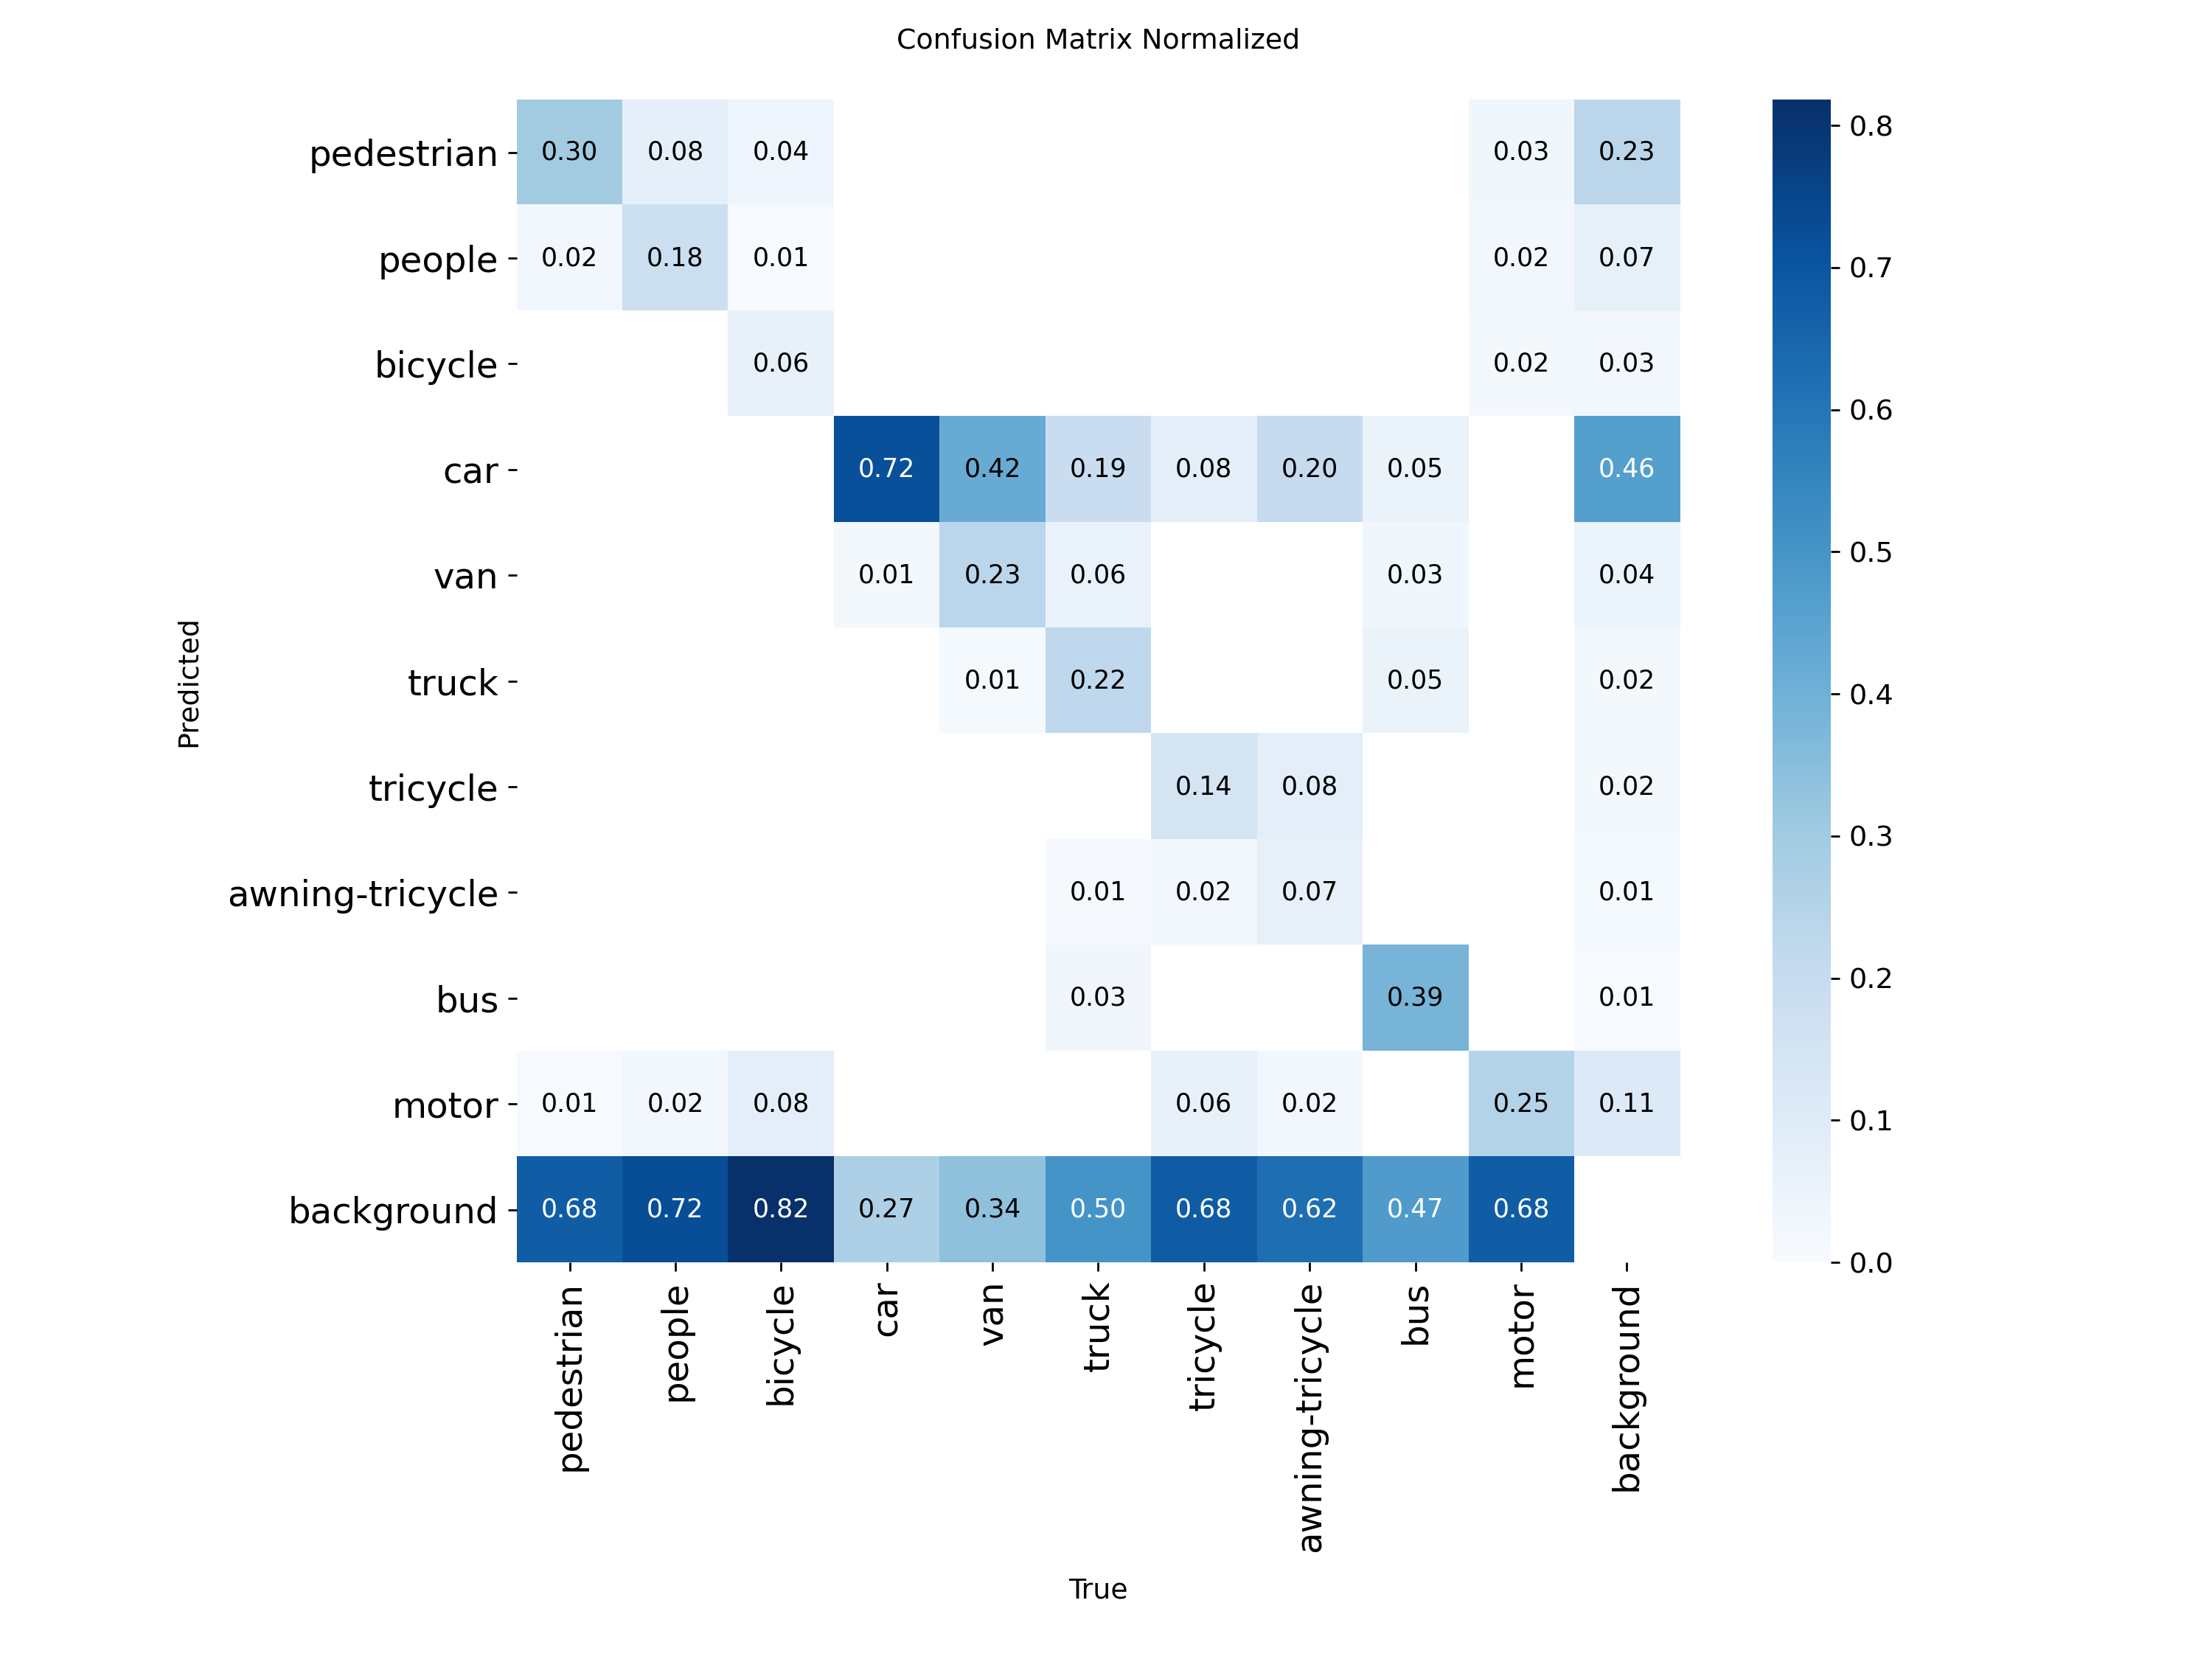

In [21]:
display(Image(filename=str(VAL_PLOTS / "confusion_matrix_normalized.png"), width=800))

### 8c. Precision-recall curve (val)

Each line is one class. As the confidence threshold falls, the model outputs more boxes: **recall**
(the share of objects found) rises, and **precision** (the share of boxes that are right) usually
falls. AP is the area under each line, and the thick line is the average over classes, which is
mAP50.

**Healthy:** curves that stay high as they move right, bowing towards the top-right corner.
**Weak class:** a curve that drops early, meaning precision collapses before much recall is gained.
**Recall ceiling:** a curve that stops well short of recall = 1.0, meaning some objects are never
found at *any* threshold. On VisDrone that is usually objects too small to resolve at 640 px, and
possibly the `max_det` ceiling from Step 3b.

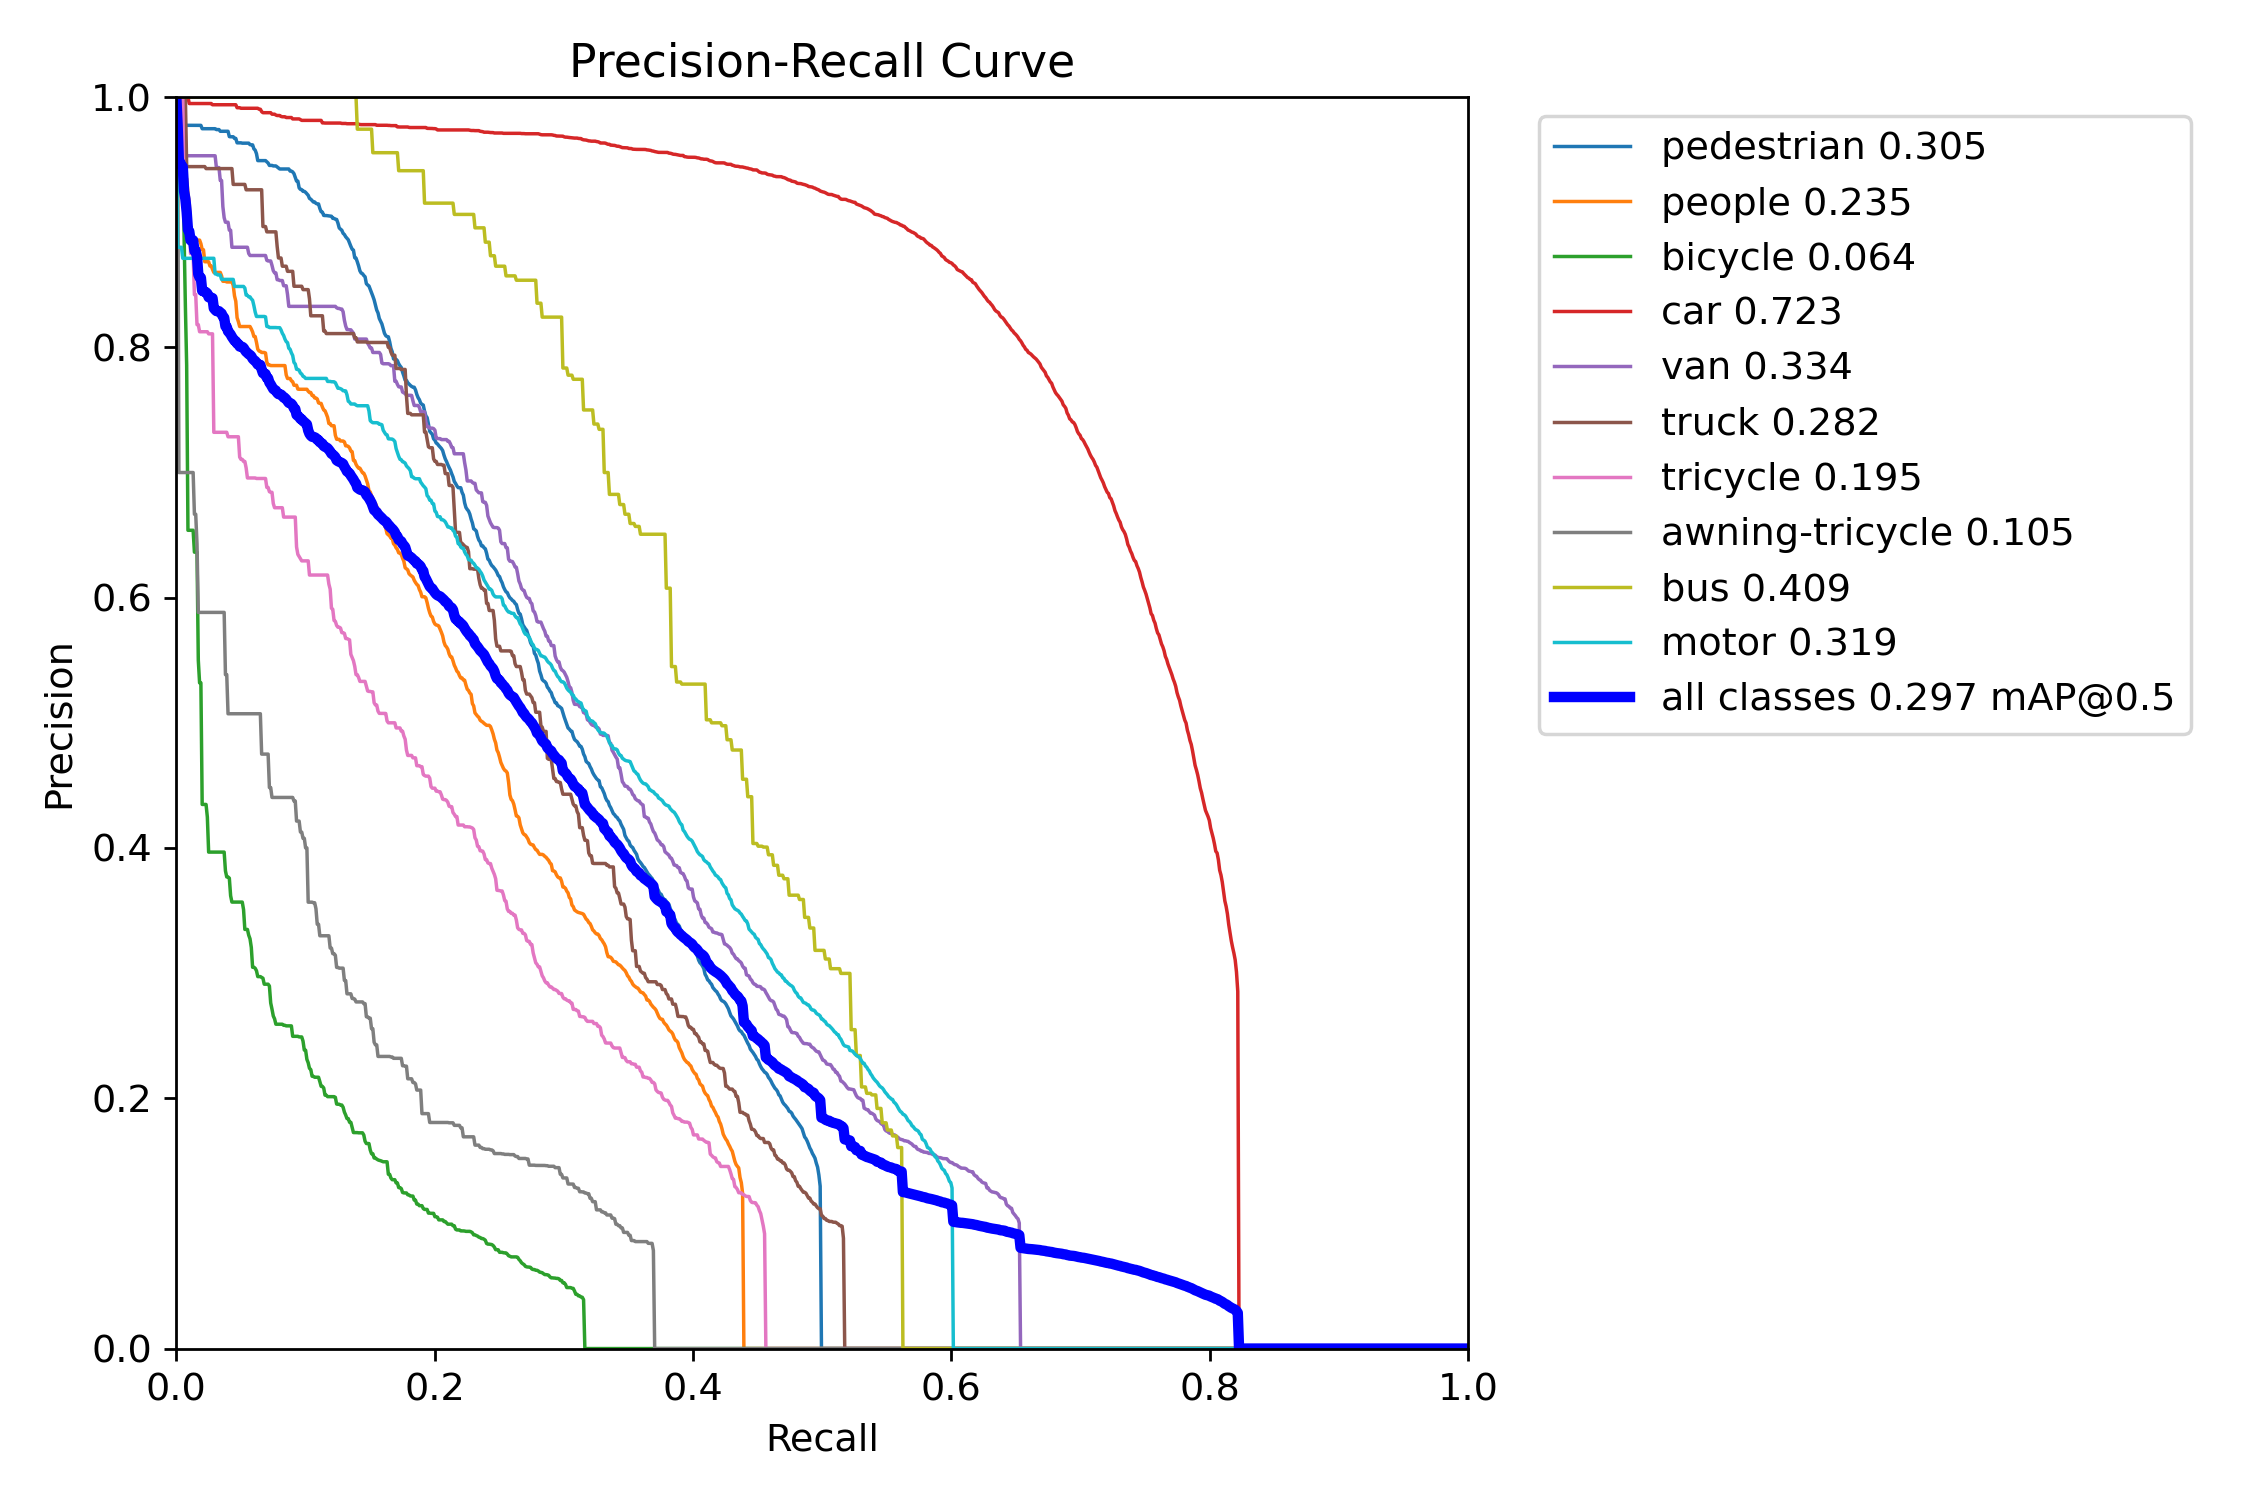

In [22]:
display(Image(filename=str(VAL_PLOTS / "BoxPR_curve.png"), width=800))

### 8d. F1 vs confidence, and the suggested deployment threshold

mAP summarises *every* threshold, but a deployed detector needs **one** threshold: keep the boxes
above it and throw away the rest. **F1** is the harmonic mean of precision and recall, and it peaks
where the two are best balanced. The confidence at that peak (mean F1 over classes, smoothed the way
Ultralytics does it) is a sensible **default deployment threshold**.

It is chosen on **val**, which is what val is for. Then the precision, recall and F1 you would
actually get at that threshold are measured on **test-dev**, which shows whether the choice holds up
on images it was not chosen on.

**Healthy:** a broad, rounded peak, so a threshold near the suggested one is not fragile. **Unhealthy:**
a sharp spike (small changes in the threshold swing the results a lot), or a peak at a very low
confidence, which suggests the model is under-confident across the board. Different uses can move the
threshold on purpose. Something that must never miss a person can sit lower and accept more false
alarms.

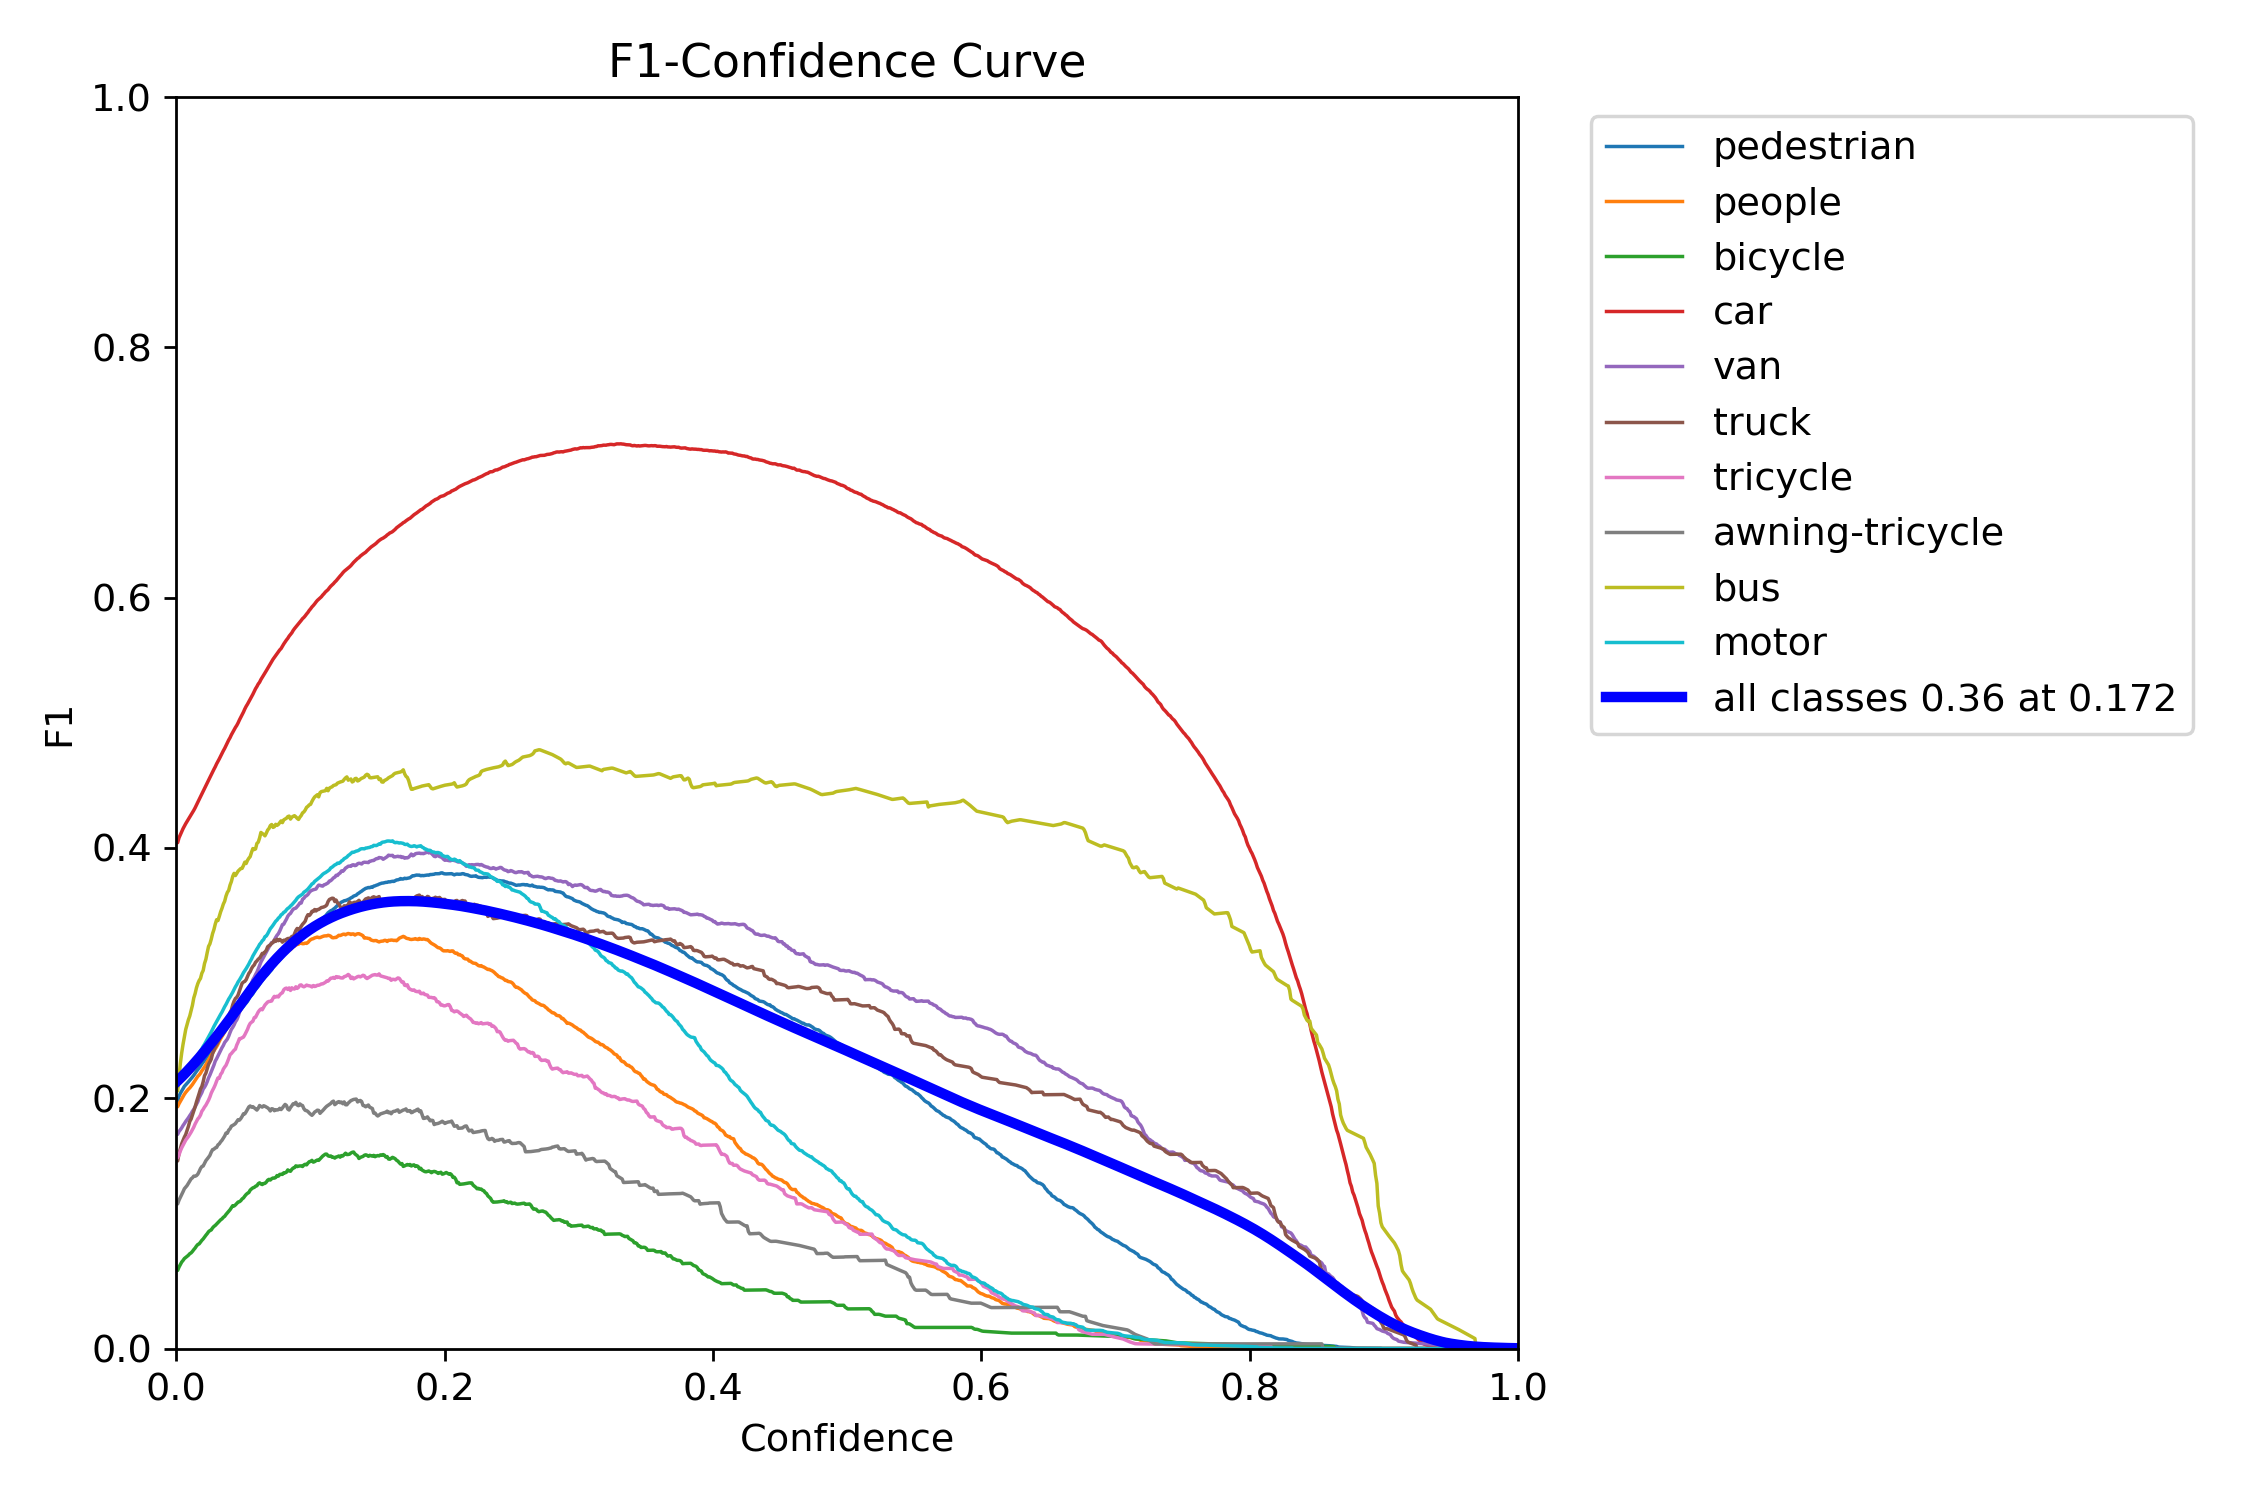

Suggested deployment confidence threshold: 0.172  (best mean F1 on val)
  at that threshold on val     : P 0.425 | R 0.324 | F1 0.360
  at that threshold on test-dev: P 0.389 | R 0.287 | F1 0.315


In [23]:
from ultralytics.utils.metrics import smooth

display(Image(filename=str(VAL_PLOTS / "BoxF1_curve.png"), width=800))

vb, tb = VAL_METRICS["val"].box, VAL_METRICS["test-dev"].box
i_best = int(smooth(vb.f1_curve.mean(0), 0.1).argmax())  # same rule Ultralytics uses for its P/R columns
SUGGESTED_CONF = {
    "value": float(vb.px[i_best]),
    "selected_on": "val",
    "criterion": "max mean-over-classes F1 (Ultralytics smoothing, f=0.1)",
    "val_at_threshold": {"precision": float(vb.p_curve.mean(0)[i_best]), "recall": float(vb.r_curve.mean(0)[i_best]),
                         "f1": float(vb.f1_curve.mean(0)[i_best])},
    "test_dev_at_threshold": {"precision": float(tb.p_curve.mean(0)[i_best]),
                              "recall": float(tb.r_curve.mean(0)[i_best]), "f1": float(tb.f1_curve.mean(0)[i_best])},
}
print(f"Suggested deployment confidence threshold: {SUGGESTED_CONF['value']:.3f}  (best mean F1 on val)")
for split, key in [("val", "val_at_threshold"), ("test-dev", "test_dev_at_threshold")]:
    s = SUGGESTED_CONF[key]
    print(f"  at that threshold on {split:8s}: P {s['precision']:.3f} | R {s['recall']:.3f} | F1 {s['f1']:.3f}")

### 8e. Predictions next to the ground truth (val)

On the left is the ground truth, and on the right what the model predicted, for the same batch of
val images. Only boxes above 0.25 confidence are drawn, because drawing all of them would bury the
image.

**Look for:** dense crowds where individuals merge into one box or are missed; tiny objects near the
top of the frame (further from the camera) with no prediction at all; vans called cars; and
"false positives" that are really **missing labels**. VisDrone's annotators missed some objects, and
a model that finds them gets penalised for it. None of this shows up in a single mAP number. That is
why these images are worth looking at.

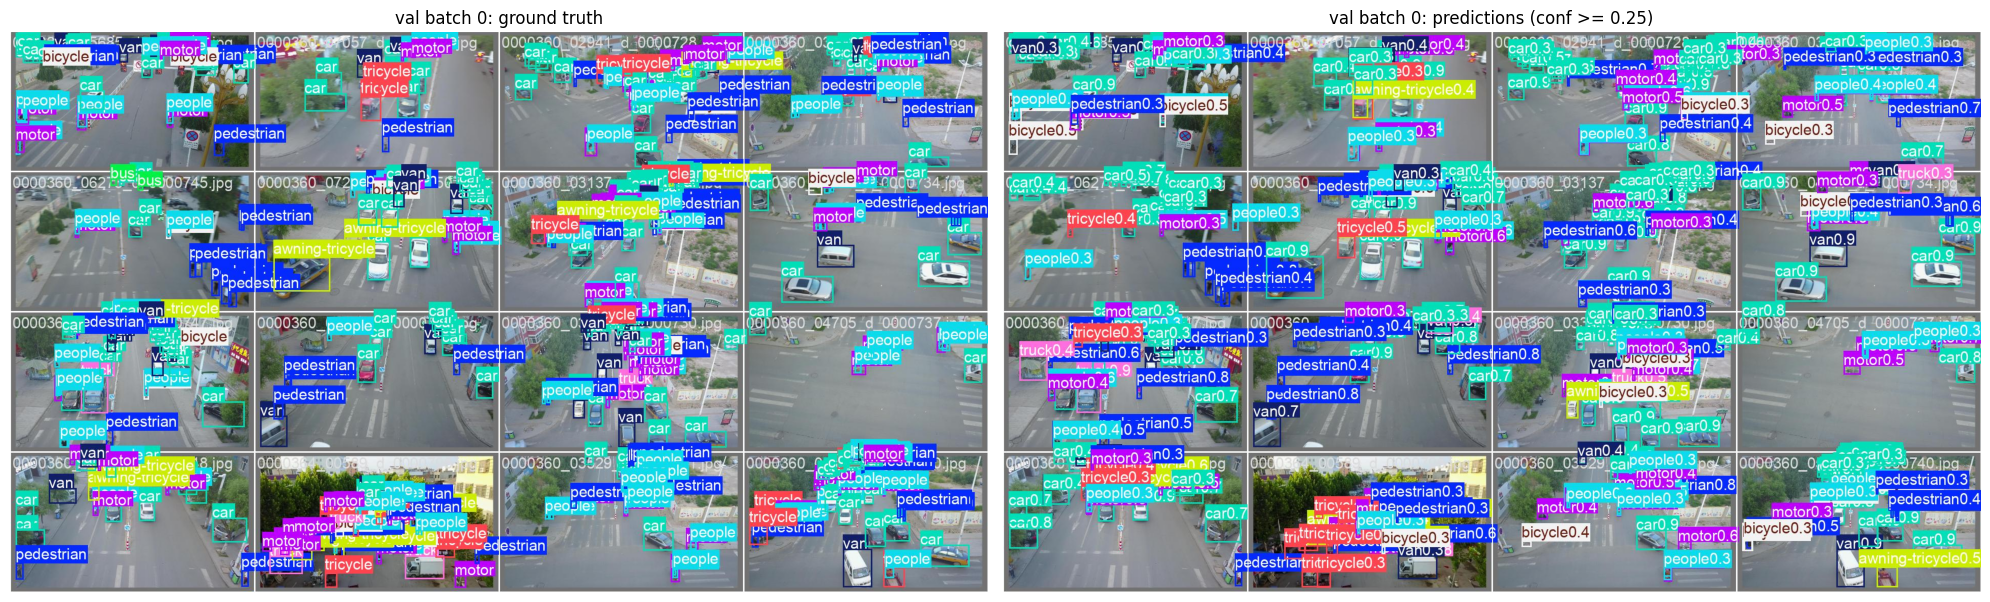

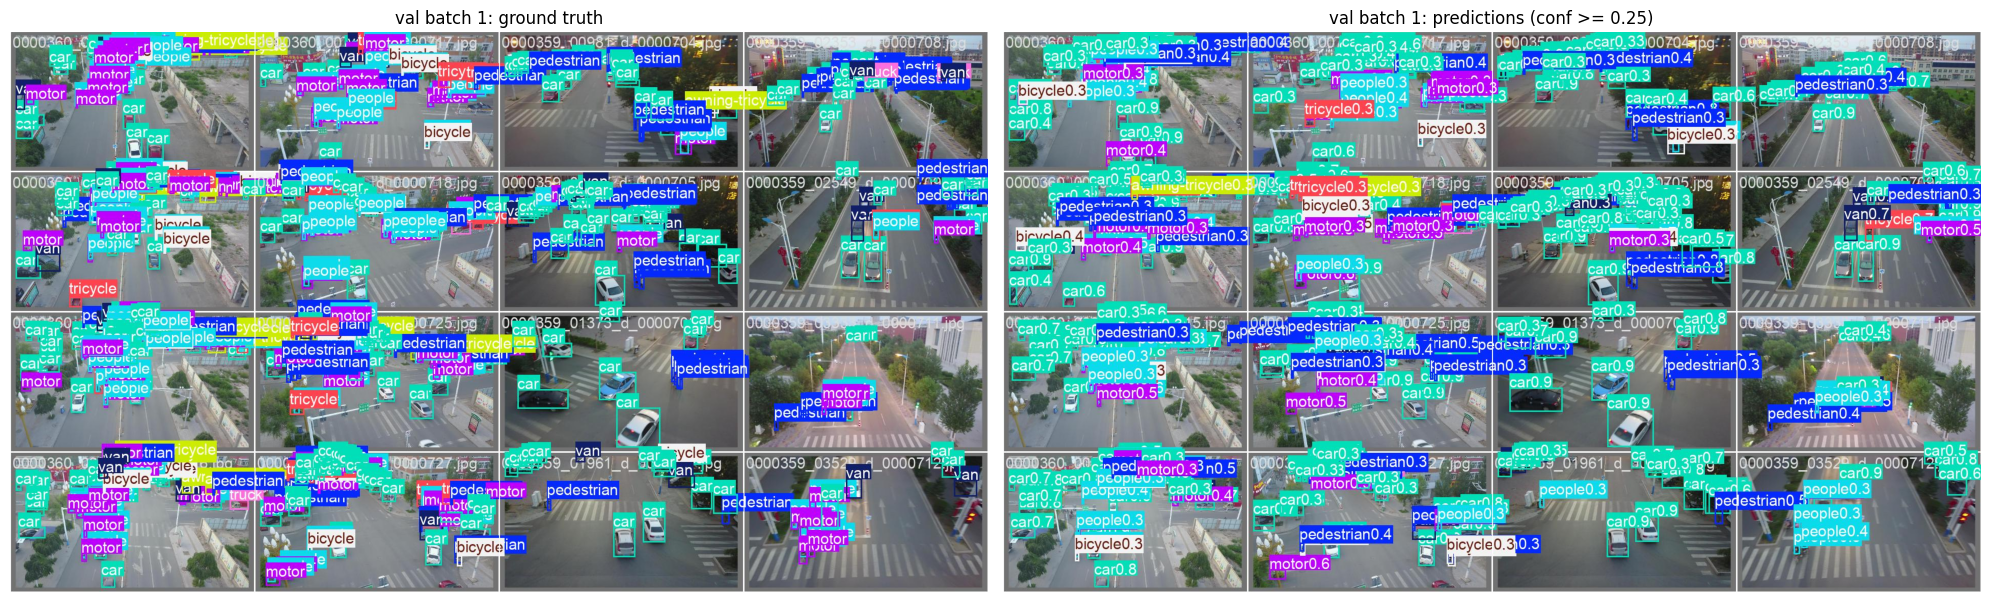

In [24]:
import matplotlib.image as mpimg

for b in range(2):
    lab, pred = VAL_PLOTS / f"val_batch{b}_labels.jpg", VAL_PLOTS / f"val_batch{b}_pred.jpg"
    if not (lab.exists() and pred.exists()):
        continue
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    for ax, f, title in [(axes[0], lab, "ground truth"), (axes[1], pred, "predictions (conf >= 0.25)")]:
        ax.imshow(mpimg.imread(f))
        ax.set_title(f"val batch {b}: {title}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### 8f. Like for like: fine-tuned vs baseline on the mapped subset

Same images, same evaluator, same merge rule, same ignore rule. The only thing that differs is the
model. **test-dev is the headline**, and val is shown alongside.

In [25]:
finetuned_raw, FT_SUBSET, FT_SUBSET_NO_IGNORE = {}, {}, {}
for split, (images, gts, _) in SPLITS.items():
    finetuned_raw[split] = predict_all(str(BEST_PT), images)
    FT_SUBSET[split], FT_SUBSET_NO_IGNORE[split] = subset_scores(
        to_eval_space(finetuned_raw[split], VISDRONE_TO_SUBSET), gts)
    for label, key in [("mAP50", "map50"), ("mAP50-95", "map50_95")]:
        b, f = BASELINE_SUBSET[split][key], FT_SUBSET[split][key]
        print(f"{split:8s} {label:9s} baseline {b:.4f} -> fine-tuned {f:.4f}  ({f - b:+.4f})")
    print(f"{split:8s} (no ignore rule: mAP50 baseline {BASELINE_SUBSET_NO_IGNORE[split]['map50']:.4f} -> "
          f"fine-tuned {FT_SUBSET_NO_IGNORE[split]['map50']:.4f})")

pd.DataFrame([
    {"class": b["class"], "test-dev instances": b["gt_instances"],
     "baseline AP50": b["ap50"], "fine-tuned AP50": f["ap50"], "delta AP50": f["ap50"] - b["ap50"],
     "baseline AP50-95": b["ap50_95"], "fine-tuned AP50-95": f["ap50_95"],
     "delta AP50-95": f["ap50_95"] - b["ap50_95"]}
    for b, f in zip(BASELINE_SUBSET["test-dev"]["per_class"], FT_SUBSET["test-dev"]["per_class"])
]).round(4)

val      mAP50     baseline 0.1302 -> fine-tuned 0.3503  (+0.2201)
val      mAP50-95  baseline 0.0739 -> fine-tuned 0.1995  (+0.1257)
val      (no ignore rule: mAP50 baseline 0.1210 -> fine-tuned 0.3397)
test-dev mAP50     baseline 0.0592 -> fine-tuned 0.3138  (+0.2545)
test-dev mAP50-95  baseline 0.0317 -> fine-tuned 0.1780  (+0.1463)
test-dev (no ignore rule: mAP50 baseline 0.0553 -> fine-tuned 0.3033)


,class,test-dev instances,baseline AP50,fine-tuned AP50,delta AP50,baseline AP50-95,fine-tuned AP50-95,delta AP50-95
0,person,27382,0.0788,0.1927,0.1139,0.0345,0.0719,0.0374
1,bicycle,1302,0.0014,0.0310,0.0296,0.0004,0.0136,0.0132
2,car,28074,0.1980,0.6771,0.4791,0.1083,0.4005,0.2922
3,truck,2659,0.0490,0.3205,0.2716,0.0287,0.1951,0.1664
4,bus,2940,0.0185,0.4729,0.4544,0.0142,0.3154,0.3012
5,motor,5845,0.0096,0.1884,0.1787,0.0042,0.0716,0.0675


### 8g. Checking the evaluator against Ultralytics

The subset numbers come from this notebook's own evaluator, so it should not be trusted without a
check. Here it scores the fine-tuned model on **all 10 classes** with no merging and no ignoring,
which is exactly what `val()` measured above, on both splits. The two will not agree to every digit,
for three reasons:

* **Matching.** This evaluator matches greedily in order of confidence, as COCO does. Ultralytics
  resolves matches by IoU.
* **Area under the curve.** The two integrate the precision-recall curve slightly differently.
* **Resizing.** `val()` resizes images in rectangular batches, while `predict()` resizes each image
  on its own.

They should be close, though: within about 0.02 mAP. A larger gap means something in the evaluator is
wrong, and the subset numbers should not be used until it is found.

In [26]:
CROSSCHECK = {}
for split, (_, gts, _) in SPLITS.items():
    ours = summarize(*evaluate(to_eval_space(finetuned_raw[split], IDENTITY_10), gts, IDENTITY_10, (),
                               VISDRONE_NAMES), VISDRONE_NAMES)
    c = {"ultralytics_map50": FT_ALL10[split]["map50"], "notebook_map50": ours["map50"],
         "ultralytics_map50_95": FT_ALL10[split]["map50_95"], "notebook_map50_95": ours["map50_95"]}
    c["max_abs_diff"] = max(abs(c["ultralytics_map50"] - c["notebook_map50"]),
                            abs(c["ultralytics_map50_95"] - c["notebook_map50_95"]))
    c["agrees"] = c["max_abs_diff"] <= 0.02
    CROSSCHECK[split] = c
    print(split, json.dumps({k: round(v, 4) if isinstance(v, float) else v for k, v in c.items()}))
    if not c["agrees"]:
        print(f"WARNING: evaluators disagree by more than 0.02 mAP on {split} - "
              "treat the mapped-subset numbers as suspect.")

val {"ultralytics_map50": 0.297, "notebook_map50": 0.2695, "ultralytics_map50_95": 0.1665, "notebook_map50_95": 0.1547, "max_abs_diff": 0.0275, "agrees": false}
test-dev {"ultralytics_map50": 0.2501, "notebook_map50": 0.2307, "ultralytics_map50_95": 0.1385, "notebook_map50_95": 0.1314, "max_abs_diff": 0.0194, "agrees": true}


## Step 9 - Save the results and export the model

### The results record

The repo keeps its benchmark results in `results/*.json`. Each file is a **list of run records**, and
each record carries a UTC `timestamp`, its configuration at the top level and a `results` list, with
metrics rounded to 4 places. This record follows the same shape. It is **appended** to
`benchmarks_visdrone.json` on Drive, so a second run adds to the file instead of overwriting the first.
`headline_split` says which split the headline numbers come from, and every metric block is keyed
by split.

**To bring it into the repo**, download `MyDrive/jarvis/visdrone_yolov8n/results/benchmarks_visdrone.json`
and commit it as `results/benchmarks_visdrone.json`.

### Why export to ONNX

`best.pt` is a PyTorch checkpoint, and loading it needs PyTorch and Ultralytics. **ONNX** is a neutral
file format for the network itself, which lightweight runtimes (ONNX Runtime, TensorRT, OpenVINO) can
run without either of them. The speed step will measure fps there, so the export is done now while
the GPU session and the weights are to hand.

It is exported at a **fixed 640x640** input size (`dynamic=False`), which matches the speed target
and lets runtimes optimise for that one shape. The cell then runs the `.pt` and the `.onnx` on the
same image and checks that they find the same boxes. A broken export usually fails silently, so this
check is worth the few seconds.

Large binaries do not go in git: the repo's `.gitignore` excludes `*.pt` and `*.onnx`. Both stay on
Drive, and only their SHA-256 hashes go into the record.

In [27]:
import hashlib


def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


EXPORT_PT = EXPORT_DIR / f"{RUN_NAME}.pt"
EXPORT_ONNX = EXPORT_DIR / f"{RUN_NAME}.onnx"
shutil.copy2(BEST_PT, EXPORT_PT)
onnx_out = YOLO(str(BEST_PT)).export(format="onnx", imgsz=IMGSZ, dynamic=False, simplify=True, half=False)
shutil.copy2(onnx_out, EXPORT_ONNX)

# Sanity check: .pt and .onnx should find the same boxes on the same image.
probe = VAL_IMAGES[0]
r_pt = YOLO(str(EXPORT_PT)).predict(probe, imgsz=IMGSZ, conf=0.25, device="cpu", verbose=False)[0].boxes
r_ox = YOLO(str(EXPORT_ONNX), task="detect").predict(probe, imgsz=IMGSZ, conf=0.25, device="cpu",
                                                    verbose=False)[0].boxes
iou = box_iou(r_pt.xyxy.numpy(), r_ox.xyxy.numpy())
same_cls = r_pt.cls.numpy()[:, None] == r_ox.cls.numpy()[None, :]
matched = float(((iou >= 0.9) & same_cls).any(1).mean()) if len(r_pt) else 1.0
ONNX_CHECK = {"probe_image": Path(probe).name, "boxes_pt": len(r_pt), "boxes_onnx": len(r_ox),
              "pt_boxes_matched_iou90": round(matched, 4)}
print(ONNX_CHECK)
if matched < 0.9:
    print("WARNING: ONNX output differs from the .pt more than expected - inspect before the speed step.")

ARTIFACTS = {
    "best_pt": {"path": str(EXPORT_PT.relative_to(DRIVE_ROOT)), "sha256": sha256(EXPORT_PT)},
    "onnx": {"path": str(EXPORT_ONNX.relative_to(DRIVE_ROOT)), "sha256": sha256(EXPORT_ONNX),
             "input_shape": [1, 3, IMGSZ, IMGSZ], "dynamic": False, "half": False},
}
print(json.dumps(ARTIFACTS, indent=2))

Ultralytics 8.4.60 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/jarvis/visdrone_yolov8n/runs/yolov8n_visdrone_640_e50_s42/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (5.9 MB)

ONNX: starting export with onnx 1.23.0 opset 20...
ONNX: slimming with onnxslim 0.1.97...
ONNX: export success ✅ 3.5s, saved as '/content/drive/MyDrive/jarvis/visdrone_yolov8n/runs/yolov8n_visdrone_640_e50_s42/weights/best.onnx' (11.7 MB)

Export complete (4.0s)
Results saved to /content/drive/MyDrive/jarvis/visdrone_yolov8n/runs/yolov8n_visdrone_640_e50_s42/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/jarvis/visdrone_yolov8n/runs/yolov8n

### Write the record

In [28]:
import platform

import onnx
import onnxruntime


def r4(x):
    # Round like the repo's results files; NaN (a class with no instances) becomes null.
    if isinstance(x, dict):
        return {k: r4(v) for k, v in x.items()}
    if isinstance(x, list):
        return [r4(v) for v in x]
    if isinstance(x, float):
        return None if np.isnan(x) else round(x, 4)
    return x


sessions = [json.loads(line) for line in SESSIONS_LOG.read_text().splitlines() if line.strip()]
record = r4({
    "timestamp": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "dataset": "visdrone2019-det",
    "headline_split": "test-dev",
    "splits": {split: {"num_images": len(gts), "skipped_images": skipped}
               for split, (_, gts, skipped) in SPLITS.items()},
    "seed": SEED,
    "versions": {
        "python": platform.python_version(), "ultralytics": ultralytics.__version__,
        "torch": torch.__version__, "torchvision": torchvision.__version__,
        "cuda": torch.version.cuda, "cudnn": torch.backends.cudnn.version(),
        "numpy": np.__version__, "onnx": onnx.__version__, "onnxruntime": onnxruntime.__version__,
    },
    "gpu": GPU_NAME,
    "gpu_sessions": sessions,
    "model": "yolov8n",
    "init_weights": "yolov8n.pt (COCO)",
    "epochs": EPOCHS,
    "epochs_completed": EPOCHS_COMPLETED,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "close_mosaic": CLOSE_MOSAIC,
    "eval": {"conf": CONF, "nms_iou": NMS_IOU, "max_det": MAX_DET,
             "iou_thresholds": "0.50:0.05:0.95", "ap_interpolation": "101-point"},
    "class_counts": {split: dict(zip(VISDRONE_NAMES, map(int, c))) for split, c in COUNTS.items()},
    "max_det_check": MAX_DET_CHECK,
    "sanity_check": SANITY,
    "mapped_subset": {
        "classes": SUBSET_NAMES,
        "coco_to_subset": {"person": "person", "bicycle": "bicycle", "car": "car",
                           "truck": "truck", "bus": "bus", "motorcycle": "motor"},
        "visdrone_to_subset": {VISDRONE_NAMES[k]: SUBSET_NAMES[v] for k, v in VISDRONE_TO_SUBSET.items()},
        "unscored": {name: "no COCO equivalent - not scored for either model on this subset"
                     for name in VISDRONE_UNSCORED.values()},
        "unscored_policy": "ignore regions: an unmatched prediction overlapping an unscored-class box at the "
                           "IoU threshold is neither TP nor FP (applied to both models)",
        "evaluator": "notebook, greedy COCO matching, re-NMS after class merge",
    },
    "results": [
        {"model": "baseline", "weights": "yolov8n.pt", "trained_on": "coco",
         "mapped_subset": BASELINE_SUBSET,
         "mapped_subset_no_ignore": BASELINE_SUBSET_NO_IGNORE,
         "all_classes": None,
         "all_classes_note": "not scored: van, tricycle, awning-tricycle have no COCO class"},
        {"model": "finetuned", "weights": ARTIFACTS["best_pt"]["path"], "trained_on": "visdrone2019-det train",
         "selected_on": "val (best fitness over epochs)",
         "mapped_subset": FT_SUBSET,
         "mapped_subset_no_ignore": FT_SUBSET_NO_IGNORE,
         "all_classes": FT_ALL10,
         "suggested_conf_threshold": SUGGESTED_CONF},
    ],
    "evaluator_crosscheck": CROSSCHECK,
    "onnx_check": ONNX_CHECK,
    "artifacts": ARTIFACTS,
})

history_records = json.loads(RESULTS_JSON.read_text()) if RESULTS_JSON.exists() else []
history_records.append(record)
RESULTS_JSON.write_text(json.dumps(history_records, indent=2) + "\n")
print(f"Appended run {len(history_records)} to {RESULTS_JSON}")
ft = record["results"][1]
print(f"HEADLINE (test-dev, all 10 classes): mAP50 {ft['all_classes']['test-dev']['map50']} | "
      f"mAP50-95 {ft['all_classes']['test-dev']['map50_95']}   "
      f"(val: {ft['all_classes']['val']['map50']} / {ft['all_classes']['val']['map50_95']})")

Appended run 2 to /content/drive/MyDrive/jarvis/visdrone_yolov8n/results/benchmarks_visdrone.json
HEADLINE (test-dev, all 10 classes): mAP50 0.2501 | mAP50-95 0.1385   (val: 0.297 / 0.1665)


## Wrap-up

What exists on Drive now (`MyDrive/jarvis/visdrone_yolov8n/`):

* `data_checks/`: the pre-training label plots (`labels.jpg`, augmented batch previews)
* `runs/<run>/`: the full training run, including `results.csv`, the curves and the confusion matrix
* `eval/finetuned_val/` and `eval/finetuned_test-dev/`: the evaluation plots for each split
* `export/<run>.pt` and `export/<run>.onnx`: the inputs to the speed step
* `results/benchmarks_visdrone.json`: the record to copy into the repo's `results/`

**Quote test-dev.** It is the number nothing was tuned on. Val is there for context, and so is the gap
between the two.

What this notebook **did not** measure: **speed**. No fps or latency number comes from here. Colab
GPUs vary from session to session and are not the target hardware, so timings taken here would not
mean much. That is the next step, and it runs against the ONNX file exported above.